# Mushroom Image Classification and Representation Analysis

**Dataset:** [Combined Kaggle Mushrooms Dataset](https://www.kaggle.com/datasets/dariobaumberger/combined-kaggle-mushrooms-dataset/data)  
**Dataset merge credit:** [Dario Baumberger](https://github.com/dario-baumberger/combined-kaggle-mushrooms-dataset)

This notebook develops a reproducible pipeline for mushroom image classification and representation analysis. The workflow proceeds from metadata validation and exploratory analysis through transfer learning, traditional classifiers trained on CNN embeddings, and descriptive clustering of learned class representations.

Several computationally expensive results are saved as external project files so that completed stages can be loaded without repeating multi-hour operations.

---

## Project Setup

### Libraries and Packages

In [1]:
# file paths and general utilities
from pathlib import Path
import copy
import math
import pickle
import random

# image handling
from PIL import Image, UnidentifiedImageError

# core analysis and plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# clustering and dimensionality reduction
import umap
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# sklearn models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# sklearn splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    top_k_accuracy_score
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder


### Project Paths and Settings

Generated `.pth`, `.pkl`, `.csv`, and `.parquet` artifacts are saved in the notebook's current working directory. These are local files rather than temporary in-memory caches. Files excluded by `.gitignore` must be backed up or transferred separately if they need to persist across computers.

In [2]:
# project data settings
image_folder = Path("images")
image_extension = ".webp"

# shared random seed
SEED = 67


In [3]:
# check path for `image` folder to load nested folder structure
print(image_folder.resolve())
print(image_folder.exists())


D:\academic\UCF\2026_summer\Data Mining 2\GroupProject\Images
True


### Reproducibility

In [4]:
# set Python, NumPy, and PyTorch randomization
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # favor repeatability over automatic CUDA performance tuning
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


---

## Exploratory Data Analysis

The exploratory analysis examines the structure, validity, class balance, and image dimensions of the dataset. These findings determine the target-label definition, stratified data split, image transformations, evaluation metrics, and later diagnostic analyses.

### Metadata Table Construction and Validation

* file\_path
* folder
* genus
* species
* label\_type
* img\_number
* width
* height
* aspect\_ratio
* valid\_image (means PIL can open/read image size)

In [5]:
# identify class folders that do not follow "Genus species" naming
folders_without_space = [
    class_dir.name
    for class_dir in sorted(image_folder.iterdir())
    if class_dir.is_dir() and " " not in class_dir.name
]

# review the one-part labels handled as non-binomial classes
print("folders without space:", len(folders_without_space))
folders_without_space[:50]

folders without space: 4


['Chroogomphus', 'Clavariaceae', 'Clavulinaceae', 'Pleurotus']

#### Metadata Construction Helpers

In [6]:
# split a folder label into its available taxonomic parts
def parse_folder_label(folder):
    folder_parts = folder.split(" ", 1)

    # parse standard two-part "Genus species" labels
    if len(folder_parts) == 2:
        genus, species = folder_parts
        label_type = "binomial"

    # retain one-part folder labels as valid non-binomial classes
    else:
        genus = folder
        species = None
        label_type = "non_binomial"

    return genus, species, label_type

In [7]:
# extract the numeric image identifier from the filename
def extract_image_number(img_path):
    return int(
        img_path.stem.rsplit("_", 1)[1]
    )

In [8]:
# inspect one image without stopping the full metadata build
def inspect_image(img_path):
    # read the image dimensions when PIL can open the file
    try:
        with Image.open(img_path) as img:
            width, height = img.size

        return {
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "valid_image": True
        }

    # retain a metadata row when an image cannot be opened
    except (UnidentifiedImageError, OSError):
        return {
            "width": None,
            "height": None,
            "aspect_ratio": None,
            "valid_image": False
        }

In [9]:
# construct one metadata row for an image
def create_metadata_row(
    img_path,
    folder
):
    # parse taxonomy from the image's class folder
    genus, species, label_type = parse_folder_label(
        folder
    )

    # collect image dimensions and validation status
    image_metadata = inspect_image(
        img_path
    )

    # combine path, class, taxonomy, and image information
    return {
        "file_path": str(img_path),
        "folder": folder,
        "genus": genus,
        "species": species,
        "label_type": label_type,
        "img_number": extract_image_number(img_path),
        **image_metadata
    }

In [10]:
# build the complete metadata table from the image folders
def build_metadata_table(
    image_folder,
    image_extension
):
    rows = []

    # collect only the class directories inside the image folder
    class_directories = [
        path
        for path in sorted(image_folder.iterdir())
        if path.is_dir()
    ]

    # construct one metadata row for every image in each class
    for class_dir in class_directories:
        image_paths = sorted(
            class_dir.glob(f"*{image_extension}")
        )

        class_rows = [
            create_metadata_row(
                img_path=img_path,
                folder=class_dir.name
            )
            for img_path in image_paths
        ]

        rows.extend(class_rows)

    # combine all image records into one table
    return pd.DataFrame(rows)

In [11]:
# define the reusable metadata cache
metadata_file = Path("image_metadata.parquet")

# load the existing table without rescanning every image
if metadata_file.exists():
    df = pd.read_parquet(
        metadata_file
    )

    print(
        "loaded metadata:",
        metadata_file
    )

# otherwise construct the table and save it for later runs
else:
    df = build_metadata_table(
        image_folder=image_folder,
        image_extension=image_extension
    )

    df.to_parquet(
        metadata_file,
        index=False
    )

    print(
        "created metadata:",
        metadata_file
    )

loaded metadata: image_metadata.parquet


In [12]:
print("total images:", len(df))
print("valid images:", df["valid_image"].sum())
print("invalid images:", (~df["valid_image"]).sum())
print(df["label_type"].value_counts()) #image counts

total images: 195411
valid images: 195411
invalid images: 0
label_type
binomial        195271
non_binomial       140
Name: count, dtype: int64


In [13]:
df = df.sort_values(["folder", "img_number"]).reset_index(drop=True)
df.head()


,file_path,folder,genus,species,label_type,img_number,width,height,aspect_ratio,valid_image
0,images\Agaricus arvensis\Agaricus arvensis_1.webp,Agaricus arvensis,Agaricus,arvensis,binomial,1,100,100,1.0,True
1,images\Agaricus arvensis\Agaricus arvensis_2.webp,Agaricus arvensis,Agaricus,arvensis,binomial,2,100,100,1.0,True
2,images\Agaricus arvensis\Agaricus arvensis_3.webp,Agaricus arvensis,Agaricus,arvensis,binomial,3,100,100,1.0,True
3,images\Agaricus arvensis\Agaricus arvensis_4.webp,Agaricus arvensis,Agaricus,arvensis,binomial,4,100,100,1.0,True
4,images\Agaricus arvensis\Agaricus arvensis_5.webp,Agaricus arvensis,Agaricus,arvensis,binomial,5,100,100,1.0,True


### Species and Genus Distribution

Each image folder is treated as one exact classification target because `ImageFolder` assigns class indices from folder names. Genus and species are also parsed from binomial folder labels for exploratory and hierarchical evaluation purposes.

This section examines:

- the number of exact class labels and genus groups;
- dominant and underrepresented classes;
- non-binomial or structurally unusual labels;
- the severity of class imbalance.

The class distribution determines whether stratification is required and whether macro-F1 should be emphasized alongside overall accuracy.

In [14]:
# Make tables for separate analysis between species and genus

# makes df with genus, species, label, and adds image count
species_counts = (
    df.groupby("folder")
    .agg(
        genus=("genus", "first"),
        species=("species", "first"),
        label_type=("label_type", "first"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# makes df with genus, species_count, and adds image count
genus_counts = (
    df.groupby("genus")
    .agg(
        species_count=("folder", "nunique"),
        image_count=("folder", "size")
    )
    .reset_index()
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# totals
print("folder/class labels:", species_counts["folder"].nunique())
print("binomial labels:", (species_counts["label_type"] == "binomial").sum())
print("non-binomial labels:", (species_counts["label_type"] == "non_binomial").sum())
print("unique species labels:", species_counts["species"].nunique())
print("unique genus labels:", genus_counts["genus"].nunique())


folder/class labels: 555
binomial labels: 551
non-binomial labels: 4
unique species labels: 522
unique genus labels: 216


In [15]:
# checking the 29 gap between species and folder/class labels
repeated_species_names = (
    species_counts[species_counts["species"].notna()]
    .groupby("species")
    .agg(
        folder_count=("folder", "nunique"),
        folders=("folder", lambda x: list(x))
    )
    .reset_index()
    .query("folder_count > 1")
    .sort_values("folder_count", ascending=False)
)

repeated_species_names


,species,folder_count,folders
440,squamosus,3,"[Cerioporus squamosus, Sarcodon squamosus, Pol..."
301,nuda,3,"[Clitocybe nuda, Collybia nuda, Lepista nuda]"
6,adusta,2,"[Bjerkandera adusta, Russula adusta]"
298,nidulans,2,"[Phyllotopsis nidulans, Hapalopilus nidulans]"
482,tubaeformis,2,"[Craterellus tubaeformis, Picipes tubaeformis]"
472,tomentosus,2,"[Phellodon tomentosus, Suillus tomentosus]"
466,tabescens,2,"[Armillaria tabescens, Desarmillaria tabescens]"
409,rufescens,2,"[Geastrum rufescens, Hydnum rufescens]"
402,rubellus,2,"[Cortinarius rubellus, Hortiboletus rubellus]"
380,pyriforme,2,"[Apioperdon pyriforme, Lycoperdon pyriforme]"


A species epithet is not necessarily unique across genera, so the full binomial folder label is retained as the supervised target rather than using the species portion alone.

In [16]:
# distribution check via simple statistics
distribution_summary = pd.DataFrame({
    "species": [
        species_counts["image_count"].min(),
        species_counts["image_count"].max(),
        species_counts["image_count"].median(),
        species_counts["image_count"].mean(),
        species_counts["image_count"].mode().iloc[0]
    ],
    "genus": [
        genus_counts["image_count"].min(),
        genus_counts["image_count"].max(),
        genus_counts["image_count"].median(),
        genus_counts["image_count"].mean(),
        genus_counts["image_count"].mode().iloc[0]
    ]
}, index=["min", "max", "median", "mean", "mode"])

distribution_summary


,species,genus
min,12.000000,25.000000
max,5823.000000,14293.000000
median,295.000000,390.000000
mean,352.091892,904.680556
mode,28.000000,31.000000


The number of unique genera is expected to be smaller than the number of exact class labels because a genus can contain several species. The four non-binomial labels do not map cleanly into the parsed genus-species structure.

In [17]:
# species level

# which species have most images
display(species_counts.head(5))

# which species have least images
species_counts.sort_values("image_count", ascending=True).head(5)


,folder,genus,species,label_type,image_count
0,Xanthoria parietina,Xanthoria,parietina,binomial,5823
1,Fomes fomentarius,Fomes,fomentarius,binomial,5245
2,Fomitopsis pinicola,Fomitopsis,pinicola,binomial,5090
3,Amanita muscaria,Amanita,muscaria,binomial,4989
4,Laetiporus sulphureus,Laetiporus,sulphureus,binomial,2958


,folder,genus,species,label_type,image_count
554,Rubroboletus pulcherrimus,Rubroboletus,pulcherrimus,binomial,12
553,Amanita fuliginea,Amanita,fuliginea,binomial,13
552,Amanita viscidolutea,Amanita,viscidolutea,binomial,13
551,Boletus pulcherrimus,Boletus,pulcherrimus,binomial,14
550,Amanita rubrovolvata,Amanita,rubrovolvata,binomial,14


In [18]:
# genus level

# which genus have most species
display(
    genus_counts
    .sort_values("species_count", ascending=False)
    [["genus", "species_count"]]
    .head(5)
)

# which genus have most images
display(
    genus_counts
    .sort_values("image_count", ascending=False)
    [["genus", "image_count"]]
    .head(5)
    )

# which genus have least images
(genus_counts
 .sort_values("image_count", ascending=True)
 [["genus", "image_count"]]
 .head(5)
 )


,genus,species_count
0,Amanita,65
3,Cortinarius,32
5,Lactarius,19
9,Tricholoma,18
8,Russula,17


,genus,image_count
0,Amanita,14293
1,Fomitopsis,6944
2,Xanthoria,5823
3,Cortinarius,5541
4,Fomes,5245


,genus,image_count
215,Neonothopanus,25
214,Kalaharituber,25
212,Podostroma,26
213,Pleurocybella,26
210,Pholiotina,28


* Can see a steep drop off in image count distribution
* Explaining:

  + mean - median positive difference trend
  + high max
  + Bottom images are closer together in value; flatter since it is close to mode.
* Distribution will have a steep fall off, but still high numbers until it baselines somewhere in the 100's and has another drop to another baseline somewhere in the 10's

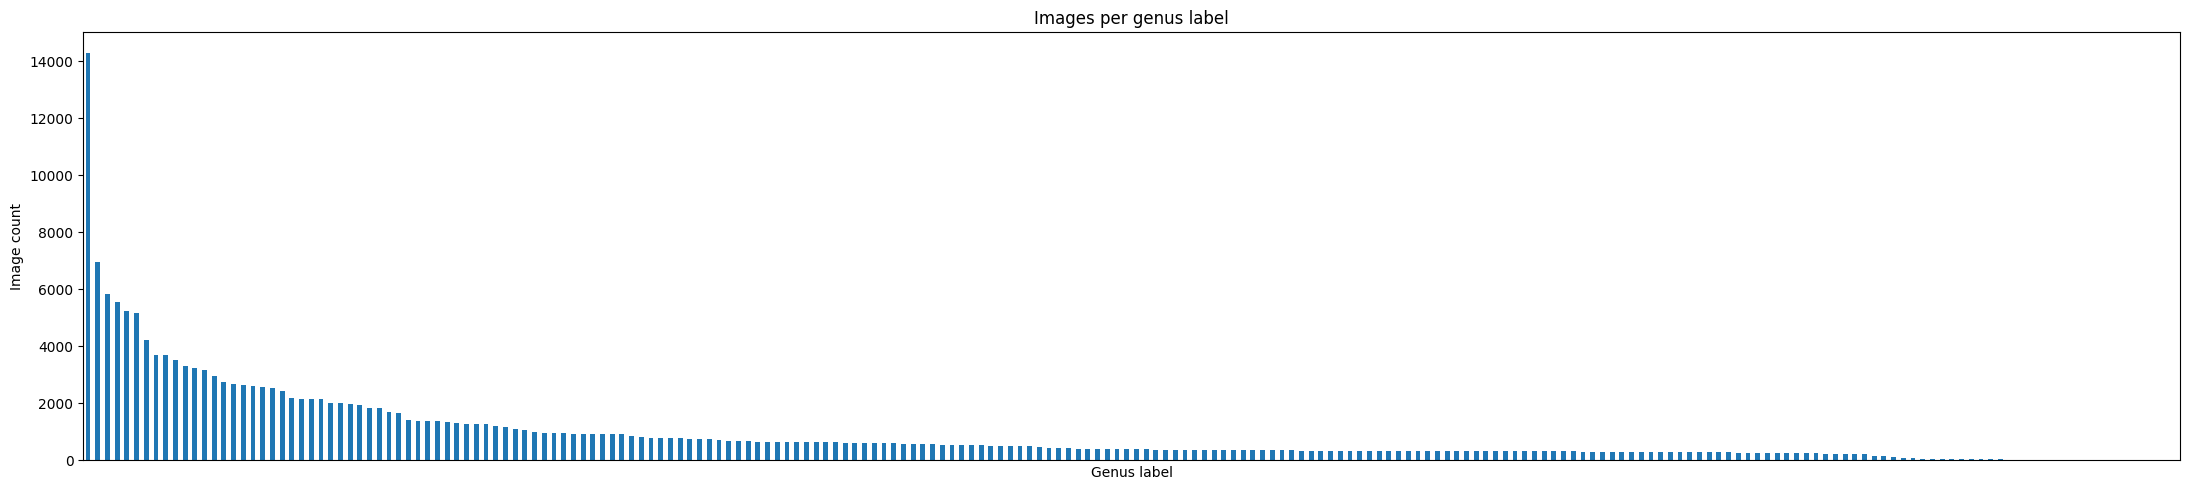

In [19]:
# genus counts
species_plot_counts = df["genus"].value_counts()

# plot image count per genus label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per genus label"
)

# labels and display
plt.xlabel("Genus label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()


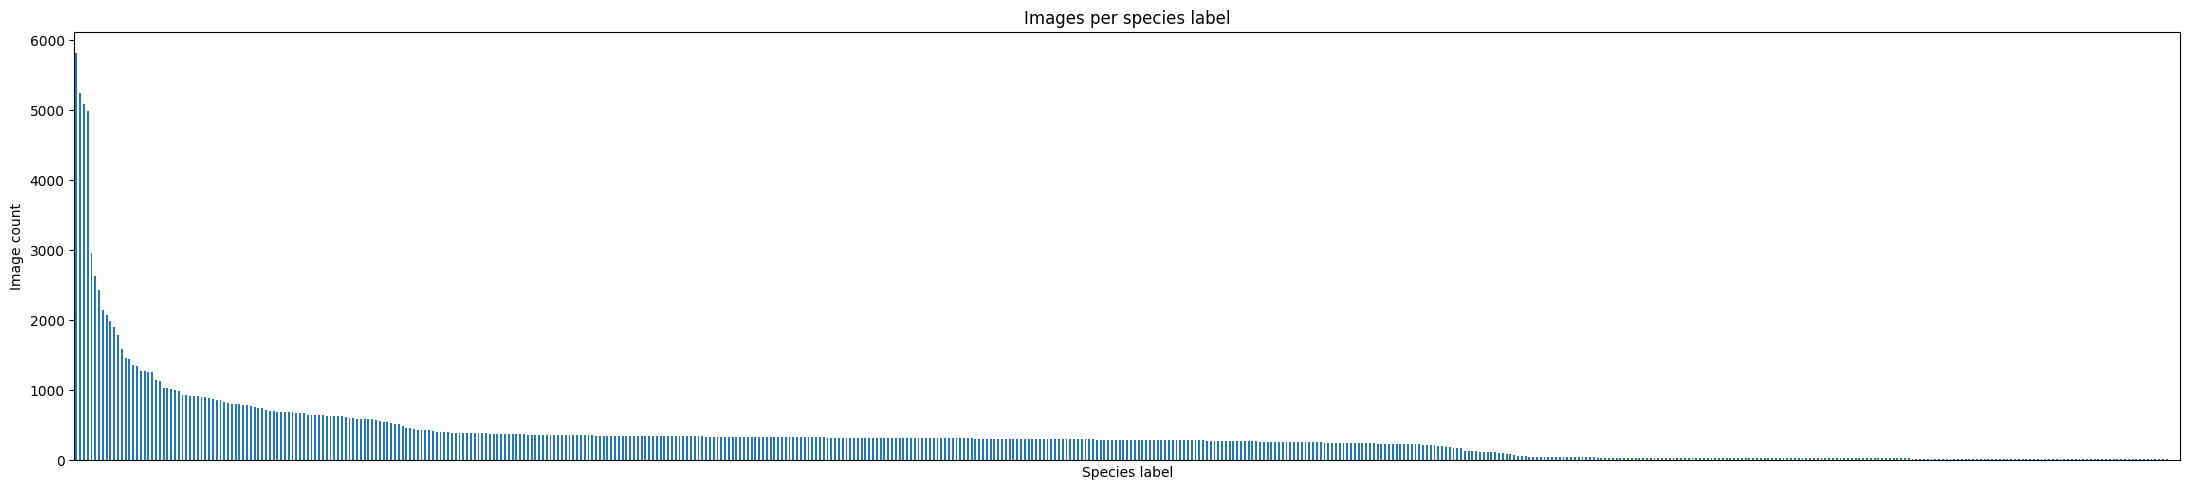

In [20]:
# species counts
species_plot_counts = df["folder"].value_counts()

# plot image count per species label
species_plot_counts.plot(
    kind="bar",
    figsize=(22, 5),
    title="Images per species label"
)

# labels and display
plt.xlabel("Species label")
plt.ylabel("Image count")
plt.xticks([])  # hide noisy species names
plt.tight_layout()
plt.show()


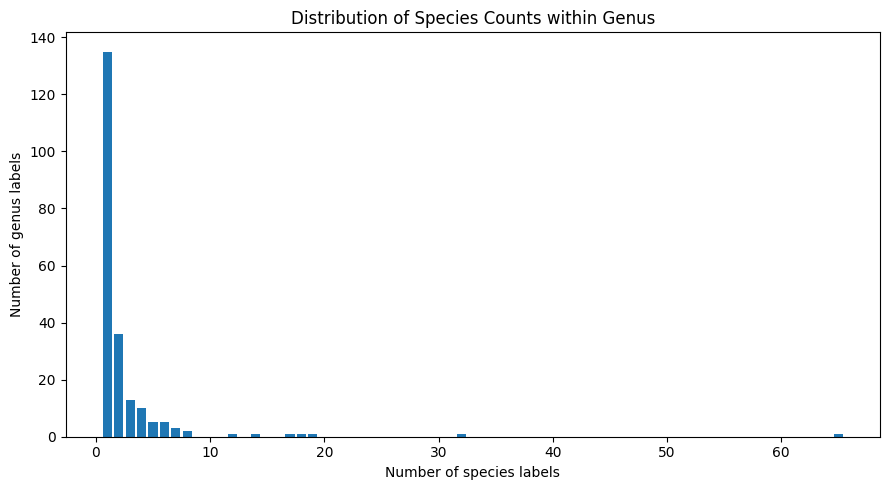

In [21]:
# count how many genus labels have 1, 2, 3, ... species labels
species_per_genus_distribution = (
    genus_counts["species_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# clean column names for plotting
species_per_genus_distribution.columns = [
    "species_labels_per_genus",
    "genus_count"
]

# slot for plot 
plt.figure(figsize=(9, 5))

# bar plot x and y for distribution check
plt.bar(
    species_per_genus_distribution["species_labels_per_genus"],
    species_per_genus_distribution["genus_count"]
)

# labels and display
plt.title("Distribution of Species Counts within Genus")
plt.xlabel("Number of species labels")
plt.ylabel("Number of genus labels")
plt.tight_layout()
plt.show()


### Image Size Analysis

The original images vary in width, height, and aspect ratio, so a common input size is required during loading.

Most images occur among a small number of common dimension combinations, while the remaining images span many low-frequency variations. Resizing all images to the fixed ResNet18 input dimensions therefore provides a consistent tensor shape without requiring the source files themselves to be rewritten.

In [22]:
# simple summary statistics
size_metric_summary = (
    df[["width", "height", "aspect_ratio"]]
    .agg(["min", "max", "median", "mean", "std"])
)

# add mode calculation
size_metric_summary.loc["mode"] = (
    df[["width", "height", "aspect_ratio"]]
    .mode()
    .iloc[0]
)

size_metric_summary


,width,height,aspect_ratio
min,90.000000,90.000000,0.252000
max,500.000000,500.000000,4.385965
median,333.000000,331.000000,1.000000
mean,340.259208,326.220458,1.070949
std,123.922141,115.129194,0.274597
mode,224.000000,224.000000,1.000000


In [23]:
# count each unique width/height/aspect-ratio combo
size_combinations = (
    df.groupby(["width", "height", "aspect_ratio"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
    .reset_index(drop=True)
)

# percent of total images for each size combo
size_combinations["percent_total"] = (
    size_combinations["image_count"] / len(df) * 100
)

# running percent to see how quickly common sizes add up
size_combinations["cumulative_percent"] = (
    size_combinations["percent_total"].cumsum()
)

size_combinations


,width,height,aspect_ratio,image_count,percent_total,cumulative_percent
0,224,224,1.000000,83614,42.788789,42.788789
1,500,375,1.333333,31288,16.011381,58.800170
2,375,500,0.750000,28257,14.460291,73.260461
3,500,333,1.501502,9216,4.716214,77.976675
4,281,500,0.562000,3529,1.805937,79.782612
...,...,...,...,...,...,...
1139,500,175,2.857143,1,0.000512,99.997953
1140,500,174,2.873563,1,0.000512,99.998465
1141,500,170,2.941176,1,0.000512,99.998977
1142,500,150,3.333333,1,0.000512,99.999488


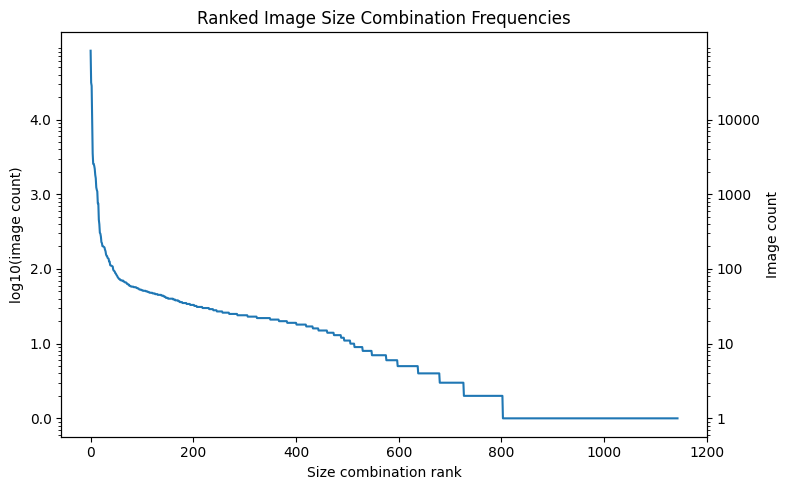

In [24]:
# raw values for log interpretation
tick_values = [1, 10, 100, 1000, 10000, 100000]
tick_values = [x for x in tick_values if x <= size_combinations["image_count"].max()]

# slot for plot 
fig, ax = plt.subplots(figsize=(8, 5))

# plot size combinations ranked by image count
ax.plot(size_combinations["image_count"].values)

# left axis as log10 values
ax.set_yscale("log")
ax.set_yticks(tick_values)
ax.set_yticklabels([round(math.log10(x), 2) for x in tick_values])
ax.set_ylabel("log10(image count)")

# right axis as raw image counts
ax_right = ax.twinx()
ax_right.set_yscale("log")
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(tick_values)
ax_right.set_yticklabels([str(x) for x in tick_values])
ax_right.set_ylabel("Image count")

# labels and display
ax.set_title("Ranked Image Size Combination Frequencies")
ax.set_xlabel("Size combination rank")
plt.tight_layout()
plt.show()


* Original images vary in size, PyTorch will need to handle resizing during loading
* Making up 100% of the image count, most of the images are in the top 5 combinations, about 80% of the images. After which it begins to fall off rapidly and then gradually decline with a high number of unique cominbations for 1 image. Like 500 x 499, 500 x 498, etc.

### Visual Inspection

This section looks directly at images to confirm EDA findings before moving on

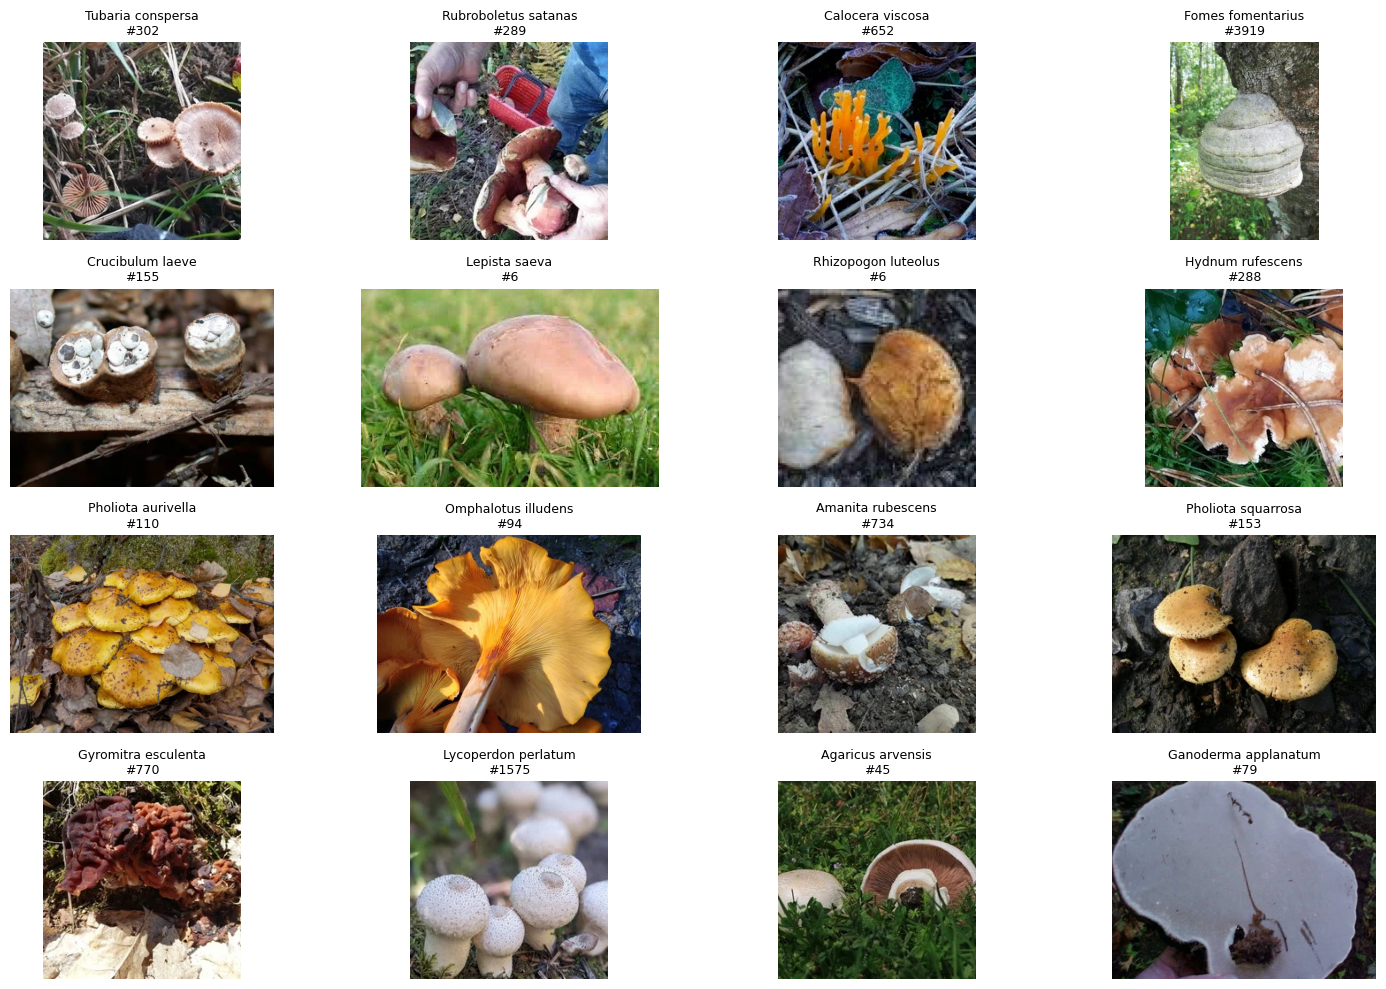

In [25]:
# random sample 16 images
sample_images = df.sample(n=16, random_state=SEED)

# create emtpy slots for images
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes = axes.flatten()

# put images into slots with file name
for ax, (_, row) in zip(axes, sample_images.iterrows()):
    img = Image.open(row["file_path"])
    ax.imshow(img)
    ax.set_title(f"{row['folder']}\n#{row['img_number']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


---

## Image Dataset Preparation

### Modeling Decisions from EDA

- The class label for modeling will be the folder label, not genus/species separated.
- Will use resnet18 pretrained imagenet 1k for standard image features like edges, textures, shapes, etc.
- Transforms will standardize image shape during loading, as well as normalization with mean and std for pretrained model expectations (according to: <https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html>).
- Will have pre-training clustering visuals of the full dataset before getting trained to our data.
- Train/test split must account for imbalance ; stratified.
- Label noise is expected and will be audited later using embeddings/clustering/model disagreement.

### ResNet18 Transforms and ImageFolder Objects

The images are resized to `224 × 224` pixels because this is the standard input size used by ResNet18.

After conversion to a tensor, each pixel channel is normalized using the ImageNet means and standard deviations that were used when the pretrained ResNet18 weights were developed.

For one channel value,

$$
x'_c
=
\frac{
x_c - \mu_c
}{
\sigma_c
}.
$$

In this notation:

- `c` identifies one image channel: red, green, or blue.
- `x_c` is the original tensor value for channel `c`.
- `x'_c`, read as “x-prime sub `c`,” is the normalized channel value.
- `μ_c` uses the lowercase Greek letter mu and is the ImageNet mean for channel `c`.
- `σ_c` uses the lowercase Greek letter sigma and is the ImageNet standard deviation for channel `c`.
- The prime symbol on `x'` indicates that the original value has been transformed.

The channel means are

```text
Red:   0.485
Green: 0.456
Blue:  0.406

In [26]:
# create the deterministic transform expected by pretrained ResNet18
def make_resnet18_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


In [27]:
# separate transform objects for training and evaluation
baseline_train_transform = make_resnet18_transform()
evaluation_transform = make_resnet18_transform()

In [28]:
# deterministic dataset used for embeddings, validation, and testing
image_dataset = ImageFolder(
    root=image_folder,
    transform=evaluation_transform
)

# separate dataset reserved for training transforms
train_image_dataset = ImageFolder(
    root=image_folder,
    transform=baseline_train_transform
)


In [29]:
# indices must refer to the same files and numeric class labels
if train_image_dataset.class_to_idx != image_dataset.class_to_idx:
    raise ValueError(
        "Training and evaluation datasets have different class mappings."
    )

if train_image_dataset.samples != image_dataset.samples:
    raise ValueError(
        "Training and evaluation datasets have different sample ordering."
    )


In [30]:
# compare PyTorch load against metadata table
# to check if image loader sees the same number of images and folders
print("ImageFolder images:", len(image_dataset))
print("DataFrame images:", len(df))

print("ImageFolder classes:", len(image_dataset.classes))
print("DataFrame folder labels:", df["folder"].nunique())


ImageFolder images: 195411
DataFrame images: 195411
ImageFolder classes: 555
DataFrame folder labels: 555


---

## Raw ResNet18 Representation Baseline

* Check how generic ImageNet features group species
* Baseline clusters

### Model and Feature Extractor Setup

In [31]:
# device and class count setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(image_dataset.classes)

print("device:", device)
print("number of classes:", num_classes)


device: cuda
number of classes: 555


In [32]:
# raw pretrained ResNet18 before mushroom training
raw_model = models.resnet18(weights="DEFAULT")
raw_model = raw_model.to(device)

# feature extractor removes final classification layer
raw_feature_extractor = nn.Sequential(
    *list(raw_model.children())[:-1]
)

raw_feature_extractor = raw_feature_extractor.to(device)
raw_feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

### Embedding Extraction and Cache

In [33]:
# extract image-level embeddings for the full dataset
def extract_image_embeddings(feature_extractor, image_dataset, batch_size=64):
    feature_loader = DataLoader(
        image_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    embedding_batches = []
    label_batches = []

    with torch.no_grad():
        for images, target in feature_loader:
            images = images.to(device)

            features = feature_extractor(images)
            features = torch.flatten(features, 1)

            embedding_batches.append(features.cpu())
            label_batches.append(target)

    embeddings = torch.cat(embedding_batches, dim=0)
    labels = torch.cat(label_batches, dim=0)

    return embeddings, labels


In [34]:
# cached full-dataset embedding file
embedding_file = Path("resnet18_embeddings.pth")


# load embeddings if they already exist
if embedding_file.exists():
    embedding_data = torch.load(
        embedding_file,
        map_location="cpu"
    )

    embeddings = embedding_data["embeddings"]
    labels = embedding_data["labels"]

    print("loaded embeddings:", embedding_file)


# otherwise extract and save them
else:
    embeddings, labels = extract_image_embeddings(
        feature_extractor=raw_feature_extractor,
        image_dataset=image_dataset,
        batch_size=64
    )

    torch.save(
        {
            "embeddings": embeddings,
            "labels": labels
        },
        embedding_file
    )

    print("created embeddings:", embedding_file)


print(embeddings.shape)
print(labels.shape)


loaded embeddings: resnet18_embeddings.pth
torch.Size([195411, 512])
torch.Size([195411])


### Class-Centroid Embeddings

The pretrained ResNet18 produces one 512-value embedding for every image. Clustering all image-level embeddings would emphasize classes containing more images, so the embeddings are first averaged within each class.

For class `c`, its centroid embedding is

$$
\bar{\mathbf{x}}_c
=
\frac{1}{n_c}
\sum_{i:y_i=c}
\mathbf{x}_i.
$$

In this notation:

- `c` represents one class folder.
- `n_c` is the number of images belonging to class `c`.
- `y_i` is the class label for image `i`.
- **x**<sub>i</sub> (**bold x** sub `i`) is the 512-value embedding for image `i`.
- **x̄**<sub>c</sub> (**bold x-bar** sub `c`) is the average embedding for class `c`.
- The bar above **x** indicates that the image embeddings have been averaged.
- `i : y_i = c` means that the sum includes only images whose label is class `c`.

This changes the representation from one row per image to one row per class. The resulting matrix contains one 512-value centroid for each of the 555 class folders.

The PCA, UMAP, K-means, and agglomerative clustering analyses below are therefore comparisons among class-level representations rather than individual images.

In [ ]:
# average image embeddings within each class folder
embedding_df = pd.DataFrame(embeddings.numpy())
embedding_df["label"] = labels.numpy()

species_embeddings = embedding_df.groupby("label").mean()
print(species_embeddings.shape)


(555, 512)


### PCA Projection

Principal Component Analysis reduces the 512 embedding features into a smaller number of new features called principal components.

Each principal component is a weighted combination of the original embedding features. For class centroid `i`, its coordinate on principal component `m` can be written as

$$
z_{im}
=
\sum_{j=1}^{p}
\left(
x_{ij} - \bar{x}_j
\right)
\phi_{jm}.
$$

In this notation:

- `i` identifies one class-centroid embedding.
- `j` identifies one original embedding feature.
- `p` is the number of original embedding features, which is `512` here.
- `m` identifies one principal component.
- `x_ij` is feature `j` from class centroid `i`.
- `x̄_j`, read as “x-bar sub `j`,” is the mean value of feature `j` across all class centroids.
- `φ_jm` uses the lowercase Greek letter phi and is the loading, or weight, assigned to feature `j` for principal component `m`.
- `z_im` is the projected coordinate of class centroid `i` on component `m`.
- `Σ`, the capital Greek letter sigma, means to add the weighted feature values from feature `1` through feature `p`.

PCA first centers each feature by subtracting its mean. It then identifies directions that capture as much variation among the class centroids as possible.

The first principal component captures the greatest possible amount of variation. The second principal component captures the greatest remaining variation while remaining perpendicular to the first.

The two-dimensional PCA plot uses only the first two components. It provides a simplified view of the class embeddings but does not contain all of the information present in the original 512-dimensional representation.

In [ ]:
# project class-centroid embeddings onto two principal components
pca = PCA(n_components=2, random_state=SEED)

embedding_pca = pca.fit_transform(species_embeddings)

### UMAP Projection

In [ ]:
# project class-centroid embeddings into two UMAP dimensions
reducer = umap.UMAP(
    n_components=2,
    random_state=SEED
)

embedding_umap = reducer.fit_transform(species_embeddings)


c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Agglomerative Clustering

Agglomerative hierarchical clustering begins with every class centroid in its
own cluster. It then repeatedly merges the two clusters that are most similar.

Ward linkage chooses the merge that produces the smallest increase in
within-cluster variation. For two candidate clusters `A` and `B`, this increase
is based on

$$
\Delta W(A,B)
=
\frac{
n_A n_B
}{
n_A + n_B
}
\left\|
\boldsymbol{\mu}_A
-
\boldsymbol{\mu}_B
\right\|^2.
$$

In this notation:

- `A` and `B` are two clusters being considered for a merge.
- `n_A` is the number of class centroids in cluster `A`.
- `n_B` is the number of class centroids in cluster `B`.
- **μ**<sub>A</sub> and **μ**<sub>B</sub> are the mean embeddings, or
  centroids, of clusters `A` and `B`.
- `Δ`, the capital Greek letter delta, represents a change.
- `W` represents within-cluster variation.
- `ΔW(A, B)` is the increase in within-cluster variation caused by merging
  clusters `A` and `B`.
- `||` **μ**<sub>A</sub> `-` **μ**<sub>B</sub> `||²` is the squared
  Euclidean distance between the two cluster centroids.

At each step, Ward linkage selects the merge associated with the smallest
increase in within-cluster variation.

In [ ]:
# group the species centroids into 20 hierarchical clusters
cluster_model = AgglomerativeClustering(
    n_clusters=20
    linkage = "ward"
)

# assign one cluster label to each species centroid
agg_clusters = cluster_model.fit_predict(
    species_embeddings
)

#### K-Means Clustering

K-means separates the class-centroid embeddings into `K` clusters. Each class is assigned to the cluster whose center is closest to its embedding.

The algorithm attempts to minimize

$$
\sum_{k=1}^{K}
\sum_{i \in C_k}
\left\|
\mathbf{x}_i - \boldsymbol{\mu}_k
\right\|^2.
$$

In this notation:

- `K` is the selected number of clusters.
- `k` identifies one cluster.
- `C_k` is the set of class centroids assigned to cluster `k`.
- `i ∈ C_k` means that class centroid `i` belongs to cluster `k`.
- **x**<sub>i</sub> (**bold x** sub `i`) is the embedding for class centroid `i`.
- **μ**<sub>k</sub> (**bold lowercase Greek mu** sub `k`) is the center of cluster `k`.
- `||` **x**<sub>i</sub> `-` **μ**<sub>k</sub> `||²` is the squared Euclidean distance between a class centroid and its cluster center.
- The two summations add these squared distances across every class and every cluster.

K-means repeatedly performs two steps:

1. Assign each class centroid to its nearest cluster center.
2. Recalculate each cluster center as the mean of the assigned class centroids.

The process continues until the cluster assignments stabilize or the stopping condition is reached.

The capital `K` used here represents the number of clusters and is separate from the lowercase `k` used in top-k classification accuracy.

In [39]:
# configure reproducible K-means clustering
kmeans = KMeans(
    n_clusters=20,
    random_state=SEED,
    n_init=10
)

# assign one K-means cluster to each species centroid
kmeans_clusters = kmeans.fit_predict(
    species_embeddings
)

c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


---

## Implement ResNet18 Representations

### PCA Projection

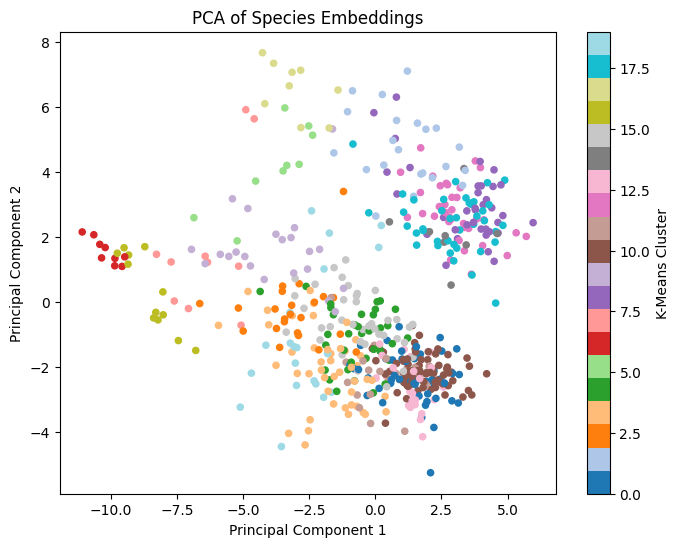

In [40]:
# display K-means clusters in the two-dimensional PCA projection
plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_pca[:, 0],
    embedding_pca[:, 1],
    c=kmeans_clusters,
    cmap="tab20",
    s=20
)

# label the PCA cluster visualization
plt.title("PCA of Species Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="K-Means Cluster")
plt.show()

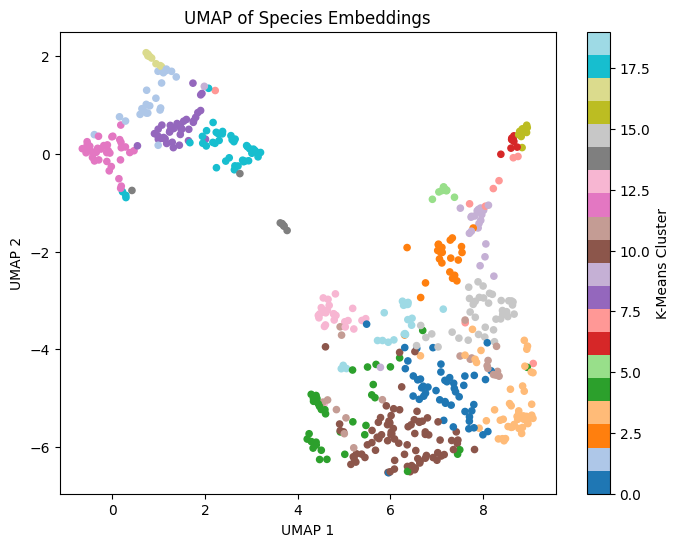

In [41]:
# display K-means clusters in the two-dimensional UMAP projection
plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_umap[:, 0],
    embedding_umap[:, 1],
    c=kmeans_clusters,
    cmap="tab20",
    s=20
)

# label the UMAP cluster visualization
plt.title("UMAP of Species Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="K-Means Cluster")
plt.show()

### Hierarchical Clustering Dendrogram

The dendrogram displays the complete sequence of Ward-linkage merges.

- Classes or clusters joined near the bottom are more similar.
- Merges occurring higher in the dendrogram combine less similar groups.
- The vertical height represents the Ward linkage value associated with a
  merge.
- Cutting the dendrogram at a chosen height produces a selected number of
  clusters.

The dendrogram height should not be interpreted as a direct distance between
two original mushroom images. It describes the hierarchical merge cost between
groups of class-centroid embeddings.

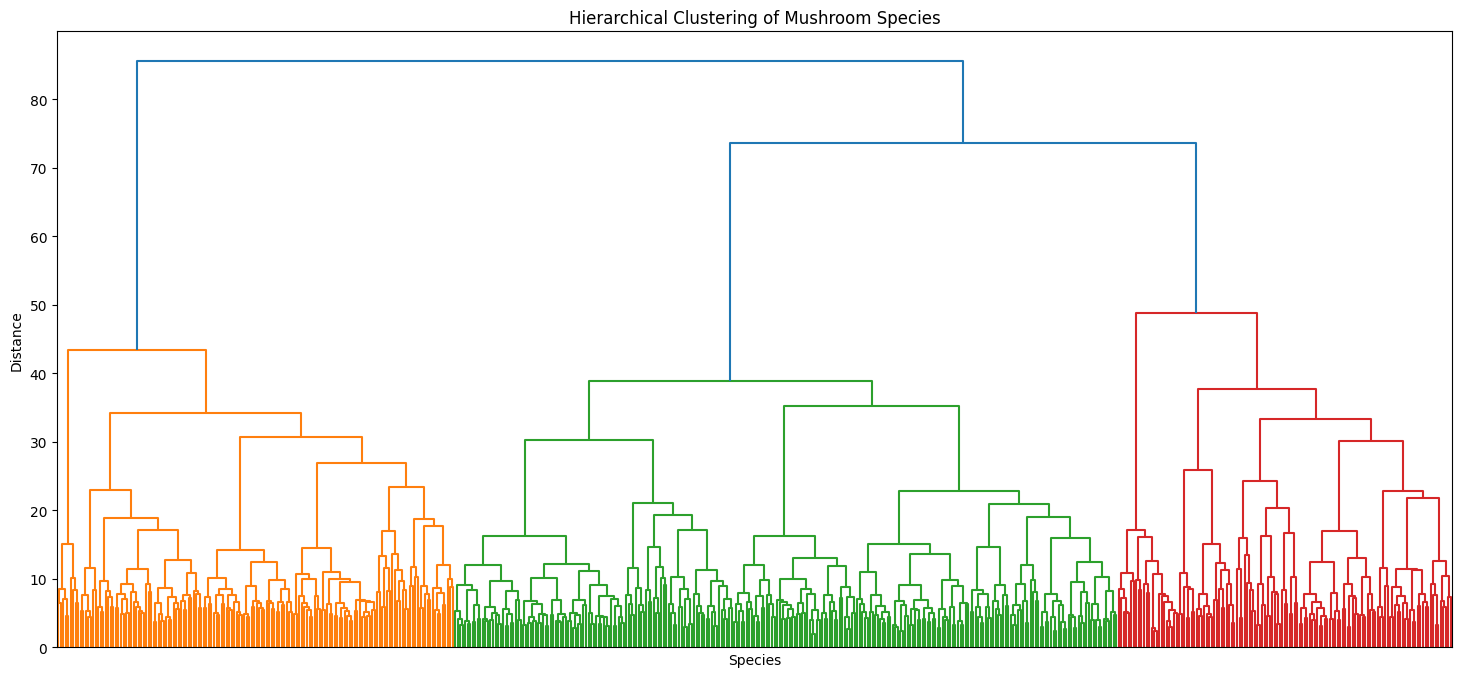

In [ ]:
# calculate the Ward-linkage hierarchy of species centroids
Z = linkage(
    species_embeddings,
    method="ward"
)

# display the full hierarchy as a dendrogram
plt.figure(figsize=(18, 8))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=None
)

# label the hierarchical clustering visualization
plt.title("Hierarchical Clustering of Mushroom Species")
plt.xlabel("Species")
plt.ylabel("Ward Linkage Value")
plt.show()

### Cluster Assignment Comparison

In [43]:
# copy the species-centroid table for cluster comparison
cluster_results = species_embeddings.copy()

# attach the assignments from both clustering methods
cluster_results["Agglomerative"] = agg_clusters
cluster_results["KMeans"] = kmeans_clusters

# preview the species embeddings and cluster assignments
cluster_results.head()

,0,1,2,3,4,5,6,7,8,9,...,504,505,506,507,508,509,510,511,Agglomerative,KMeans
label,,,,,,,,,,,,,,,,,,,,,
0,0.641581,0.423239,0.558378,1.079590,0.732316,0.707837,0.533030,0.604729,0.689805,0.645508,...,1.747051,0.403470,0.843804,0.926658,0.822564,0.310018,1.250640,0.654151,11,10
1,0.774870,0.417319,0.685024,0.972998,0.663994,0.796123,0.680969,0.599082,0.795399,0.754530,...,2.685983,0.463989,1.007971,1.035202,0.883684,0.464353,0.964801,0.560225,1,4
2,0.712695,0.451406,0.695645,1.488162,0.955559,0.816602,0.850002,0.553511,0.733584,0.483635,...,1.909559,0.424242,1.106223,0.842366,0.847117,0.290932,1.150743,0.466898,1,4
3,0.337549,0.399781,0.919717,0.359812,1.077749,0.271092,0.990493,1.046836,0.259625,0.749598,...,2.100396,0.293681,0.351937,1.303529,0.561449,0.209406,0.623459,0.449192,4,1
4,0.443474,0.396879,0.647044,0.546260,0.749056,0.638223,0.807196,0.728262,0.574111,0.757951,...,1.645075,0.141328,0.430812,0.643443,0.564100,0.224622,0.910482,0.484522,13,8


---

## Supervised CNN Modeling

### Train, Validation, and Test Split

In [44]:
# set the train, validation, and test proportions
train_size = 0.70
val_size = 0.15
test_size = 0.15

# collect the numeric class labels and image indices
targets = image_dataset.targets
indices = list(range(len(image_dataset)))

# separate training data from the combined validation/test holdout
train_indices, holdout_indices = train_test_split(
    indices,
    train_size=train_size,
    stratify=targets,
    random_state=SEED
)

# collect the class labels corresponding to the holdout images
holdout_targets = [
    targets[index]
    for index in holdout_indices
]

# divide the holdout equally into validation and test data
val_indices, test_indices = train_test_split(
    holdout_indices,
    test_size=test_size / (val_size + test_size),
    stratify=holdout_targets,
    random_state=SEED
)

# apply the training transform to the training subset
train_dataset = Subset(
    train_image_dataset,
    train_indices
)

# apply the deterministic transform to validation and test subsets
val_dataset = Subset(
    image_dataset,
    val_indices
)

test_dataset = Subset(
    image_dataset,
    test_indices
)

# verify the resulting split sizes
print("train images:", len(train_dataset))
print("validation images:", len(val_dataset))
print("test images:", len(test_dataset))

print(
    "total images:",
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
)

train images: 136787
validation images: 29312
test images: 29312
total images: 195411


### DataLoaders and Reproducibility

In [45]:
# shared DataLoader settings
batch_size = 32

# Windows and Jupyter work most reliably without worker subprocesses
num_workers = 0

# use page-locked memory when transferring batches to a GPU
pin_memory = torch.cuda.is_available()

In [ ]:
# create a reproducible DataLoader for one dataset split
def make_data_loader(dataset, shuffle):
    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        generator=generator
    )

In [47]:
# create the shuffled training loader
train_loader = make_data_loader(
    dataset=train_dataset,
    shuffle=True
)

# preserve validation ordering during evaluation
val_loader = make_data_loader(
    dataset=val_dataset,
    shuffle=False
)

# preserve test ordering for final evaluation
test_loader = make_data_loader(
    dataset=test_dataset,
    shuffle=False
)

# display the number of batches in each split
print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 4275
validation batches: 916
test batches: 916


---

### Shared CNN Infrastructure

#### Model and Training Helpers

In [48]:
# build a ResNet18 classifier for the mushroom classes
def build_resnet18_classifier(
    num_classes,
    device,
    weights="DEFAULT"
):
    # load the requested ResNet18 weights
    model = models.resnet18(weights=weights)

    # replace the ImageNet classifier with the project classifier
    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model.to(device)

In [49]:
# train a model for one complete pass through the training data
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    # enable training behavior such as dropout and batch normalization updates
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    # process each training batch
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # clear gradients from the previous batch
        optimizer.zero_grad()

        # calculate predictions and training loss
        outputs = model(images)
        loss = criterion(outputs, labels)

        # update the trainable model parameters
        loss.backward()
        optimizer.step()

        # accumulate loss and classification counts
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # calculate full-epoch training metrics
    train_loss = running_loss / total
    train_accuracy = correct / total

    return train_loss, train_accuracy

In [50]:
# freeze the ResNet18 backbone and train only the classifier
def freeze_backbone_train_fc(model):
    # freeze all model parameters
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze the final classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

#### Evaluation Metrics and Helpers

The evaluation process first collects model outputs for an entire DataLoader and then calculates the shared exact-class, candidate-list, and genus-level metrics.

In [51]:
# folder-label to genus lookup

# map each dataset folder label to its genus
folder_to_genus = (
    df[["folder", "genus"]]
    .drop_duplicates()
    .set_index("folder")["genus"]
    .to_dict()
)

# align each numeric class index with its genus name
class_genus_names = [
    folder_to_genus[class_label]
    for class_label in image_dataset.classes
]

# create numeric indices for the unique genera
genus_names = sorted(set(class_genus_names))

genus_to_idx = {
    genus: index
    for index, genus in enumerate(genus_names)
}

# map every class index to its corresponding genus index
class_index_to_genus_index = torch.tensor([
    genus_to_idx[genus]
    for genus in class_genus_names
])

In [52]:
# collect loss, labels, and model outputs from one loader
def collect_model_outputs(
    model,
    loader,
    criterion,
    device
):
    # disable training behavior during evaluation
    model.eval()

    running_loss = 0
    total = 0

    label_batches = []
    output_batches = []

    # evaluate each batch without calculating gradients
    with torch.no_grad():
        for images, labels in loader:
            # move the current batch to the selected device
            images = images.to(device)
            labels = labels.to(device)

            # calculate model outputs and batch loss
            outputs = model(images)
            loss = criterion(outputs, labels)

            # accumulate loss and sample counts
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

            # retain outputs on the CPU for later metrics
            label_batches.append(labels.cpu())
            output_batches.append(outputs.cpu())

    # combine all evaluation batches
    average_loss = running_loss / total
    all_labels = torch.cat(label_batches, dim=0)
    all_outputs = torch.cat(output_batches, dim=0)

    return average_loss, all_labels, all_outputs

##### Exact-Class Accuracy

Exact-class accuracy measures the proportion of evaluated images whose top-1 predicted class matches the true class.

For `n` evaluated images,

$$
\text{Accuracy}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbf{1}
\left[
\hat{y}_i = y_i
\right].
$$

In this notation:

- `n` is the total number of evaluated images.
- `i` identifies one evaluated image.
- `y_i` is the true class label for image `i`.
- `ŷ_i`, read as “y-hat sub `i`,” is the model's top-1 predicted class for image `i`.
- The hat above `y` distinguishes a predicted value from the true value.
- `1[condition]` is an indicator function that equals `1` when the condition is true and `0` otherwise.
- `Σ`, the capital Greek letter sigma, means to add the indicator results across all evaluated images.

Accuracy treats every evaluated image equally. However, it can be influenced by large classes when the dataset is imbalanced.

##### Macro-F1 and Weighted-F1

Precision measures how often predictions for a class are correct:

$$
\text{Precision}_c
=
\frac{TP_c}{TP_c + FP_c}.
$$

Recall measures how many images from a class are identified correctly:

$$
\text{Recall}_c
=
\frac{TP_c}{TP_c + FN_c}.
$$

The F1 score combines precision and recall using their harmonic mean:

$$
F1_c
=
2
\frac{
\text{Precision}_c
\text{Recall}_c
}{
\text{Precision}_c
+
\text{Recall}_c
}.
$$

In this notation:

- `c` represents one class.
- `TP_c` is the number of true positives for class `c`.
- `FP_c` is the number of false positives for class `c`.
- `FN_c` is the number of false negatives for class `c`.
- `F1_c` is the F1 score calculated for class `c`.

Macro-F1 gives every class equal influence by averaging the individual class F1 scores:

$$
\text{Macro-F1}
=
\frac{1}{C}
\sum_{c=1}^{C}
F1_c.
$$

In this notation:

- `C` is the total number of classes.
- `c` identifies one class, ranging from class `1` through class `C`.
- `F1_c` is the F1 score for class `c`.

Weighted-F1 accounts for class size by weighting each class F1 score by its number of evaluated images:

$$
\text{Weighted-F1}
=
\sum_{c=1}^{C}
\frac{n_c}{n}
F1_c.
$$

In this notation:

- `n_c` is the number of evaluated images belonging to class `c`.
- `n_c / n` is the proportion of evaluated images belonging to class `c`.
- Larger classes therefore contribute more strongly to weighted-F1.

Macro-F1 is the primary validation metric in this project because it gives small and large classes equal influence. Weighted-F1 is retained as a supplementary metric that reflects performance across the observed class distribution.

In [53]:
# calculate exact-class, top-k, and genus-level metrics
def calculate_evaluation_metrics(
    labels,
    outputs,
    class_index_to_genus_index,
    top_k_values=(3, 5)
):
    # select the highest-scoring class for each image
    predictions = outputs.argmax(dim=1)

    # convert tensors for sklearn metric functions
    labels_array = labels.numpy()
    predictions_array = predictions.numpy()
    outputs_array = outputs.numpy()

    # calculate exact-class performance
    accuracy = accuracy_score(
        labels_array,
        predictions_array
    )

    macro_f1 = f1_score(
        labels_array,
        predictions_array,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        labels_array,
        predictions_array,
        average="weighted",
        zero_division=0
    )

    # map true and predicted classes to genus indices
    class_to_genus = class_index_to_genus_index.cpu()

    true_genus = class_to_genus[labels]
    predicted_genus = class_to_genus[predictions]

    # identify exact-class errors that remain within the correct genus
    same_genus = true_genus == predicted_genus
    incorrect = predictions != labels

    genus_accuracy = same_genus.float().mean().item()

    class_error_count = incorrect.sum().item()
    same_genus_error_count = (
        incorrect & same_genus
    ).sum().item()

    # avoid division by zero when there are no exact-class errors
    same_genus_error_rate = 0

    if class_error_count > 0:
        same_genus_error_rate = (
            same_genus_error_count
            / class_error_count
        )

    # store the shared evaluation metrics
    metrics = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "genus_accuracy": genus_accuracy,
        "same_genus_error_rate": same_genus_error_rate
    }

    # calculate each requested candidate-list accuracy
    for k in top_k_values:
        metrics[f"top_{k}_accuracy"] = top_k_accuracy_score(
            labels_array,
            outputs_array,
            k=k,
            labels=np.arange(outputs.shape[1])
        )

    return metrics, predictions_array

In [54]:
# evaluate one model on a given loader
def evaluate_model(
    model,
    loader,
    criterion,
    device,
    class_index_to_genus_index,
    top_k_values=(3, 5),
    return_details=False
):
    # collect outputs from one complete evaluation pass
    loss, labels, outputs = collect_model_outputs(
        model=model,
        loader=loader,
        criterion=criterion,
        device=device
    )

    # calculate metrics from the collected outputs
    metrics, predictions = calculate_evaluation_metrics(
        labels=labels,
        outputs=outputs,
        class_index_to_genus_index=class_index_to_genus_index,
        top_k_values=top_k_values
    )

    metrics["loss"] = loss

    # return only summary metrics for standard experiments
    if not return_details:
        return metrics

    # retain detailed outputs when diagnostics are required
    details = {
        "labels": labels.numpy(),
        "predictions": predictions,
        "outputs": outputs
    }

    return metrics, details

---

## Frozen-Backbone CNN Baseline

### Baseline Configuration

In [55]:
# define the baseline checkpoint
baseline_checkpoint_file = Path(
    "baseline_resnet18_epoch1.pth"
)

# reset randomization before model construction and training
set_seed()

# recreate the shuffled training loader
train_loader = make_data_loader(
    dataset=train_dataset,
    shuffle=True
)

# match the classifier output to the dataset classes
num_classes = len(image_dataset.classes)

# avoid loading pretrained weights when restoring a checkpoint
if baseline_checkpoint_file.exists():
    initial_weights = None
else:
    initial_weights = "DEFAULT"

# build the baseline ResNet18 classifier
model = build_resnet18_classifier(
    num_classes=num_classes,
    device=device,
    weights=initial_weights
)

print("device:", device)
print("number of classes:", num_classes)
print(
    "checkpoint exists:",
    baseline_checkpoint_file.exists()
)

device: cuda
number of classes: 555
checkpoint exists: True


In [56]:
# freeze the backbone and leave only the classifier trainable
model = freeze_backbone_train_fc(model)

# use unweighted multiclass cross-entropy for the baseline
criterion = nn.CrossEntropyLoss()

# update only the final classifier parameters
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [ ]:
# count the parameters updated by the baseline optimizer
trainable_params = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

print("trainable parameters:", trainable_params)

trainable parameters: 284715


### One-Epoch Baseline Execution

In [58]:
# load the existing baseline or train it for one epoch
if baseline_checkpoint_file.exists():
    checkpoint = torch.load(
        baseline_checkpoint_file,
        map_location=device
    )

    # confirm that the saved class mapping matches the dataset
    if checkpoint["class_to_idx"] != image_dataset.class_to_idx:
        raise ValueError(
            "Checkpoint class mapping does not match "
            "the current dataset."
        )

    # restore the saved model and training results
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    train_loss = checkpoint["train_loss"]
    train_accuracy = checkpoint["train_accuracy"]

    print(
        "loaded baseline checkpoint:",
        baseline_checkpoint_file
    )

else:
    # train the classifier for one complete epoch
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    print("trained one-epoch baseline")

# display the training results
print("train loss:", train_loss)
print("train accuracy:", train_accuracy)

loaded baseline checkpoint: baseline_resnet18_epoch1.pth
train loss: 3.256663819168193
train accuracy: 0.33804381995365057


In [59]:
# evaluate the one-epoch baseline
val_metrics, val_details = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    class_index_to_genus_index=class_index_to_genus_index,
    top_k_values=(3, 5),
    return_details=True
)

# retain detailed outputs for baseline diagnostics
all_labels = val_details["labels"]
all_predictions = val_details["predictions"]
all_outputs = val_details["outputs"]

# retain names used by later experiment cells
val_loss = val_metrics["loss"]
val_accuracy = val_metrics["accuracy"]
val_macro_f1 = val_metrics["macro_f1"]
val_weighted_f1 = val_metrics["weighted_f1"]

val_top_3_accuracy = val_metrics["top_3_accuracy"]
val_top_5_accuracy = val_metrics["top_5_accuracy"]

val_genus_accuracy = val_metrics["genus_accuracy"]
val_same_genus_error_rate = val_metrics["same_genus_error_rate"]

# display the validation summary
pd.Series(
    val_metrics,
    name="value"
).to_frame()

,value
accuracy,0.411026
macro_f1,0.232644
weighted_f1,0.393127
genus_accuracy,0.466498
same_genus_error_rate,0.094184
top_3_accuracy,0.589486
top_5_accuracy,0.661709
loss,2.641843


In [60]:
# save the baseline only when no checkpoint exists
if not baseline_checkpoint_file.exists():
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_to_idx": image_dataset.class_to_idx,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_metrics": val_metrics,
            "seed": SEED,
            "transform": (
                "Resize(224,224) + ToTensor "
                "+ ImageNet Normalize"
            ),
            "split": "70/15/15 stratified",
            "model": (
                "ResNet18 pretrained, frozen backbone, "
                "trained final layer"
            )
        },
        baseline_checkpoint_file
    )

    print(
        "created baseline checkpoint:",
        baseline_checkpoint_file
    )

### Baseline Diagnostics

#### Per-Class Performance and Class Imbalance

The following diagnostics compare validation performance across classes and examine whether the number of available training images is associated with precision, recall, and F1.

In [61]:
# per-class validation metrics
class_indices = np.arange(num_classes)

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=class_indices,
    zero_division=0
)

# count training images available for each class
train_targets = [
    targets[index]
    for index in train_indices
]

train_class_counts = (
    pd.Series(train_targets)
    .value_counts()
    .reindex(class_indices, fill_value=0)
)

# count total images available for each class
total_class_counts = (
    pd.Series(targets)
    .value_counts()
    .reindex(class_indices, fill_value=0)
)

# validation performance by class
class_metrics = pd.DataFrame({
    "class_index": class_indices,
    "class_label": image_dataset.classes,
    "train_images": train_class_counts.values,
    "total_images": total_class_counts.values,
    "val_support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1
})

class_metrics.sort_values(by='f1', ascending=False).head()

,class_index,class_label,train_images,total_images,val_support,precision,recall,f1
551,551,Xanthoria parietina,4076,5823,873,0.850498,0.879725,0.864865
54,54,Amanita muscaria,3492,4989,749,0.874116,0.825100,0.848901
91,91,Artomyces pyxidatus,891,1273,191,0.755274,0.937173,0.836449
109,109,Calocera viscosa,551,787,118,0.830508,0.830508,0.830508
259,259,Hericium coralloides,633,905,136,0.820896,0.808824,0.814815


In [62]:
# best validation F1 scores with at least 20 validation images
supported_class_metrics = class_metrics[
    class_metrics["val_support"] >= 20
]

supported_class_metrics.sort_values(
    "f1",
    ascending=False
).head(10)

,class_index,class_label,train_images,total_images,val_support,precision,recall,f1
551,551,Xanthoria parietina,4076,5823,873,0.850498,0.879725,0.864865
54,54,Amanita muscaria,3492,4989,749,0.874116,0.825100,0.848901
91,91,Artomyces pyxidatus,891,1273,191,0.755274,0.937173,0.836449
109,109,Calocera viscosa,551,787,118,0.830508,0.830508,0.830508
259,259,Hericium coralloides,633,905,136,0.820896,0.808824,0.814815
454,454,Rhytisma acerinum,561,801,120,0.867925,0.766667,0.814159
293,293,Inonotus obliquus,653,933,140,0.837209,0.771429,0.802974
479,479,Sarcoscypha austriaca,442,632,95,0.750000,0.852632,0.798030
244,244,Gyromitra gigas,1017,1453,218,0.825000,0.756881,0.789474
257,257,Hericium americanum,228,326,49,0.888889,0.653061,0.752941


In [63]:
# worst validation F1 scores with at least 20 validation images
supported_class_metrics.sort_values(
    "f1"
).head(10)

,class_index,class_label,train_images,total_images,val_support,precision,recall,f1
404,404,Phaeonematoloma myosotis,153,218,32,0.0,0.0,0.0
429,429,Pluteus cervinus,226,323,48,0.0,0.0,0.0
415,415,Pholiota lenta,214,305,46,0.0,0.0,0.0
145,145,Clitopilus prunulus,181,258,39,0.0,0.0,0.0
525,525,Tricholoma pessundatum,94,134,20,0.0,0.0,0.0
526,526,Tricholoma saponaceum,248,355,54,0.0,0.0,0.0
148,148,Collybiopsis peronata,228,326,49,0.0,0.0,0.0
272,272,Hygrophorus pustulatus,213,304,46,0.0,0.0,0.0
376,376,Mycena plumipes,165,235,35,0.0,0.0,0.0
375,375,Mycena metata,146,209,31,0.0,0.0,0.0


In [64]:
# classes with validation images but zero recall
zero_recall_classes = class_metrics[
    (class_metrics["val_support"] > 0)
    & (class_metrics["recall"] == 0)
].sort_values(
    ["train_images", "val_support"],
    ascending=False
)

print(
    "classes with zero validation recall:",
    len(zero_recall_classes)
)

zero_recall_classes.head(20)

classes with zero validation recall: 159


,class_index,class_label,train_images,total_images,val_support,precision,recall,f1
307,307,Lactarius helvus,255,365,55,0.0,0.0,0.0
526,526,Tricholoma saponaceum,248,355,54,0.0,0.0,0.0
148,148,Collybiopsis peronata,228,326,49,0.0,0.0,0.0
429,429,Pluteus cervinus,226,323,48,0.0,0.0,0.0
415,415,Pholiota lenta,214,305,46,0.0,0.0,0.0
272,272,Hygrophorus pustulatus,213,304,46,0.0,0.0,0.0
16,16,Agrocybe praecox,205,293,44,0.0,0.0,0.0
370,370,Mycena galericulata,205,293,44,0.0,0.0,0.0
286,286,Inocybe geophylla,197,282,43,0.0,0.0,0.0
15,15,Agrocybe pediades,188,269,40,0.0,0.0,0.0


In [65]:
# relationship between class size and validation performance
class_metrics[
    [
        "train_images",
        "total_images",
        "val_support",
        "f1"
    ]
].corr()

,train_images,total_images,val_support,f1
train_images,1.000000,1.000000,0.999988,0.464466
total_images,1.000000,1.000000,0.999990,0.464503
val_support,0.999988,0.999990,1.000000,0.464701
f1,0.464466,0.464503,0.464701,1.000000


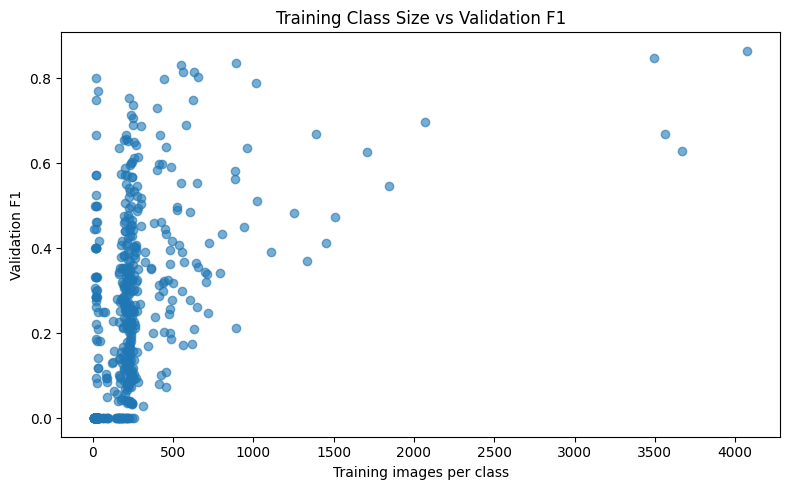

In [66]:
# training class size versus validation F1
plt.figure(figsize=(8, 5))

plt.scatter(
    class_metrics["train_images"],
    class_metrics["f1"],
    alpha=0.6
)

plt.title("Training Class Size vs Validation F1")
plt.xlabel("Training images per class")
plt.ylabel("Validation F1")
plt.tight_layout()
plt.show()

Classes with more training images generally show better validation performance,
but class size does not fully explain the results. Some medium-sized classes
still have zero recall, indicating that the frozen ImageNet representation may
not separate all mushroom species effectively.

This suggests two different limitations:

- **Class imbalance:** Some classes provide substantially fewer training
  examples than others.
- **Representation limitation:** Some classes remain difficult even when their
  training sample size is not especially small.

These findings motivate testing additional training, partial ResNet18
fine-tuning, and class-weighted loss.

### High-Confidence Error Audit

In [67]:
# connect each validation prediction to its source image
val_file_paths = [
    image_dataset.samples[index][0]
    for index in val_indices
]

# convert saved labels back to a PyTorch tensor for indexing
all_labels_tensor = torch.as_tensor(
    all_labels,
    dtype=torch.long
)

# convert model logits into class probabilities
probabilities = torch.softmax(
    all_outputs,
    dim=1
)

# retain the probability assigned to the predicted class
all_confidences = (
    probabilities
    .max(dim=1)
    .values
    .numpy()
)

# retain the probability assigned to the true class
all_true_probs = probabilities[
    torch.arange(len(all_labels_tensor)),
    all_labels_tensor
].numpy()

# rank every class from highest to lowest model output
ranked_indices = all_outputs.argsort(
    dim=1,
    descending=True
)

# locate the true class within each ranked prediction list
true_class_rank = (
    ranked_indices
    == all_labels_tensor.unsqueeze(1)
).int().argmax(dim=1).add(1).numpy()

In [68]:
# map numeric class indices to readable class and genus labels
class_index_to_label = dict(
    enumerate(image_dataset.classes)
)

class_index_to_genus_name = dict(
    enumerate(class_genus_names)
)

# combine prediction details for every validation image
val_diagnostics = pd.DataFrame({
    "file_path": val_file_paths,
    "true_index": all_labels,
    "predicted_index": all_predictions,
    "confidence": all_confidences,
    "true_class_probability": all_true_probs,
    "true_class_rank": true_class_rank
})

# attach readable class labels
val_diagnostics["true_label"] = (
    val_diagnostics["true_index"]
    .map(class_index_to_label)
)

val_diagnostics["predicted_label"] = (
    val_diagnostics["predicted_index"]
    .map(class_index_to_label)
)

# attach readable genus labels
val_diagnostics["true_genus"] = (
    val_diagnostics["true_index"]
    .map(class_index_to_genus_name)
)

val_diagnostics["predicted_genus"] = (
    val_diagnostics["predicted_index"]
    .map(class_index_to_genus_name)
)

# identify exact-class correctness and genus agreement
val_diagnostics["correct"] = (
    val_diagnostics["true_index"]
    == val_diagnostics["predicted_index"]
)

val_diagnostics["same_genus"] = (
    val_diagnostics["true_genus"]
    == val_diagnostics["predicted_genus"]
)

# measure how much more confidence was assigned to the prediction
val_diagnostics["confidence_gap"] = (
    val_diagnostics["confidence"]
    - val_diagnostics["true_class_probability"]
)

val_diagnostics.head()

,file_path,true_index,predicted_index,confidence,true_class_probability,true_class_rank,true_label,predicted_label,true_genus,predicted_genus,correct,same_genus,confidence_gap
0,images\Hebeloma crustuliniforme\Hebeloma crust...,248,363,0.102779,0.042655,4,Hebeloma crustuliniforme,Melanoleuca cognata,Hebeloma,Melanoleuca,False,False,0.060124
1,images\Leccinum versipelle\Leccinum versipelle...,329,220,0.237041,0.001837,46,Leccinum versipelle,Fomes fomentarius,Leccinum,Fomes,False,False,0.235204
2,images\Xanthoria parietina\Xanthoria parietina...,551,551,0.552155,0.552155,1,Xanthoria parietina,Xanthoria parietina,Xanthoria,Xanthoria,True,True,0.000000
3,images\Flammulina velutipes\Flammulina velutip...,219,414,0.180419,0.022932,9,Flammulina velutipes,Pholiota aurivella,Flammulina,Pholiota,False,False,0.157487
4,images\Hypogymnia physodes\Hypogymnia physodes...,278,278,0.818734,0.818734,1,Hypogymnia physodes,Hypogymnia physodes,Hypogymnia,Hypogymnia,True,True,0.000000


In [69]:
# isolate incorrect top-1 validation predictions
confident_wrong = (
    val_diagnostics[
        ~val_diagnostics["correct"]
    ]
    .sort_values(
        [
            "confidence",
            "true_class_probability"
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# inspect the most confident mistakes
confident_wrong[
    [
        "true_label",
        "predicted_label",
        "true_genus",
        "predicted_genus",
        "same_genus",
        "confidence",
        "true_class_probability",
        "true_class_rank"
    ]
].head(20)

,true_label,predicted_label,true_genus,predicted_genus,same_genus,confidence,true_class_probability,true_class_rank
0,Helvella lacunosa,Craterellus cornucopioides,Helvella,Craterellus,False,0.997101,0.001959,2
1,Amanita persicina,Amanita muscaria,Amanita,Amanita,True,0.996542,0.003422,2
2,Armillaria borealis,Fomitopsis betulina,Armillaria,Fomitopsis,False,0.996117,0.000641,2
3,Physcia adscendens,Xanthoria parietina,Physcia,Xanthoria,False,0.995801,0.000093,8
4,Hericium erinaceus,Lycoperdon perlatum,Hericium,Lycoperdon,False,0.995627,0.000053,14
5,Crucibulum laeve,Calycina citrina,Crucibulum,Calycina,False,0.995384,0.002392,2
6,Amanita persicina,Amanita muscaria,Amanita,Amanita,True,0.992762,0.005321,2
7,Fomitopsis betulina,Fomes fomentarius,Fomitopsis,Fomes,False,0.992308,0.002717,2
8,Fomitopsis mounceae,Fomitopsis pinicola,Fomitopsis,Fomitopsis,True,0.991823,0.002101,2
9,Evernia prunastri,Xanthoria parietina,Evernia,Xanthoria,False,0.991725,0.000160,9


In [70]:
# summarize repeated true-class and predicted-class combinations
confusion_pairs = (
    confident_wrong
    .groupby(
        [
            "true_label",
            "predicted_label",
            "same_genus"
        ],
        as_index=False
    )
    .agg(
        error_count=("file_path", "size"),
        mean_confidence=("confidence", "mean"),
        max_confidence=("confidence", "max"),
        mean_true_rank=("true_class_rank", "mean")
    )
    .sort_values(
        [
            "error_count",
            "mean_confidence"
        ],
        ascending=[False, False]
    )
)

# inspect the most frequent and confident confusion pairs
confusion_pairs.head(20)

,true_label,predicted_label,same_genus,error_count,mean_confidence,max_confidence,mean_true_rank
7068,Parmelia sulcata,Hypogymnia physodes,False,105,0.469068,0.948118,2.809524
3726,Fomitopsis pinicola,Fomes fomentarius,False,104,0.595961,0.989707,3.519231
3528,Evernia mesomorpha,Evernia prunastri,True,65,0.608887,0.976659,2.953846
3871,Ganoderma applanatum,Fomes fomentarius,False,50,0.493649,0.934434,5.360000
9909,Vulpicida pinastri,Xanthoria parietina,False,38,0.607553,0.966956,2.131579
3670,Fomitopsis betulina,Fomes fomentarius,False,38,0.583493,0.992308,2.578947
3538,Evernia prunastri,Hypogymnia physodes,False,38,0.453844,0.783373,2.973684
4891,Hypogymnia physodes,Parmelia sulcata,False,36,0.465815,0.843631,2.250000
7809,Pseudevernia furfuracea,Evernia prunastri,False,35,0.586901,0.963748,3.371429
1165,Apioperdon pyriforme,Lycoperdon pyriforme,False,31,0.411336,0.750984,2.258065


In [71]:
# measure how often top-1 errors are recovered by a candidate list
top_k_error_recovery = pd.Series({
    "top_3_recovered_errors": (
        confident_wrong["true_class_rank"] <= 3
    ).mean(),

    "top_5_recovered_errors": (
        confident_wrong["true_class_rank"] <= 5
    ).mean()
})

# display recovery as a proportion of all top-1 errors
top_k_error_recovery.to_frame(
    name="proportion_of_top_1_errors"
)

,proportion_of_top_1_errors
top_3_recovered_errors,0.303000
top_5_recovered_errors,0.425626


* confidence\_order = "desc" high confidence first
* confidence\_order = "asc" low confidence first
* confidence\_order = None random assortment

In [72]:
# visualize images from one true/predicted class pair
def plot_confusion_pair(
    true_label,
    predicted_label,
    n=12,
    confidence_order="desc"
):
    # select validation images matching the confusion pair
    pair_examples = val_diagnostics[
        (val_diagnostics["true_label"] == true_label)
        & (
            val_diagnostics["predicted_label"]
            == predicted_label
        )
    ]

    # order or sample the matching examples
    if confidence_order == "desc":
        pair_examples = pair_examples.sort_values(
            "confidence",
            ascending=False
        )

    elif confidence_order == "asc":
        pair_examples = pair_examples.sort_values(
            "confidence"
        )

    elif confidence_order is None:
        pair_examples = pair_examples.sample(
            n=min(n, len(pair_examples)),
            random_state=SEED
        )

    else:
        raise ValueError(
            "confidence_order must be "
            "'desc', 'asc', or None"
        )

    pair_examples = pair_examples.head(n)

    # stop when the requested confusion pair does not occur
    if pair_examples.empty:
        print(
            "No examples found for this "
            "true/predicted pair."
        )
        return

    # create the image grid
    columns = 4
    rows = math.ceil(
        len(pair_examples) / columns
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.5 * rows)
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    # display each image and its prediction details
    for ax, (_, row) in zip(
        axes,
        pair_examples.iterrows()
    ):
        with Image.open(row["file_path"]) as image:
            display_image = image.convert("RGB")

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Confidence: {row['confidence']:.3f}\n"
            f"True rank: {row['true_class_rank']}"
        )

        ax.imshow(display_image)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    # hide unused positions in the image grid
    for ax in axes[len(pair_examples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

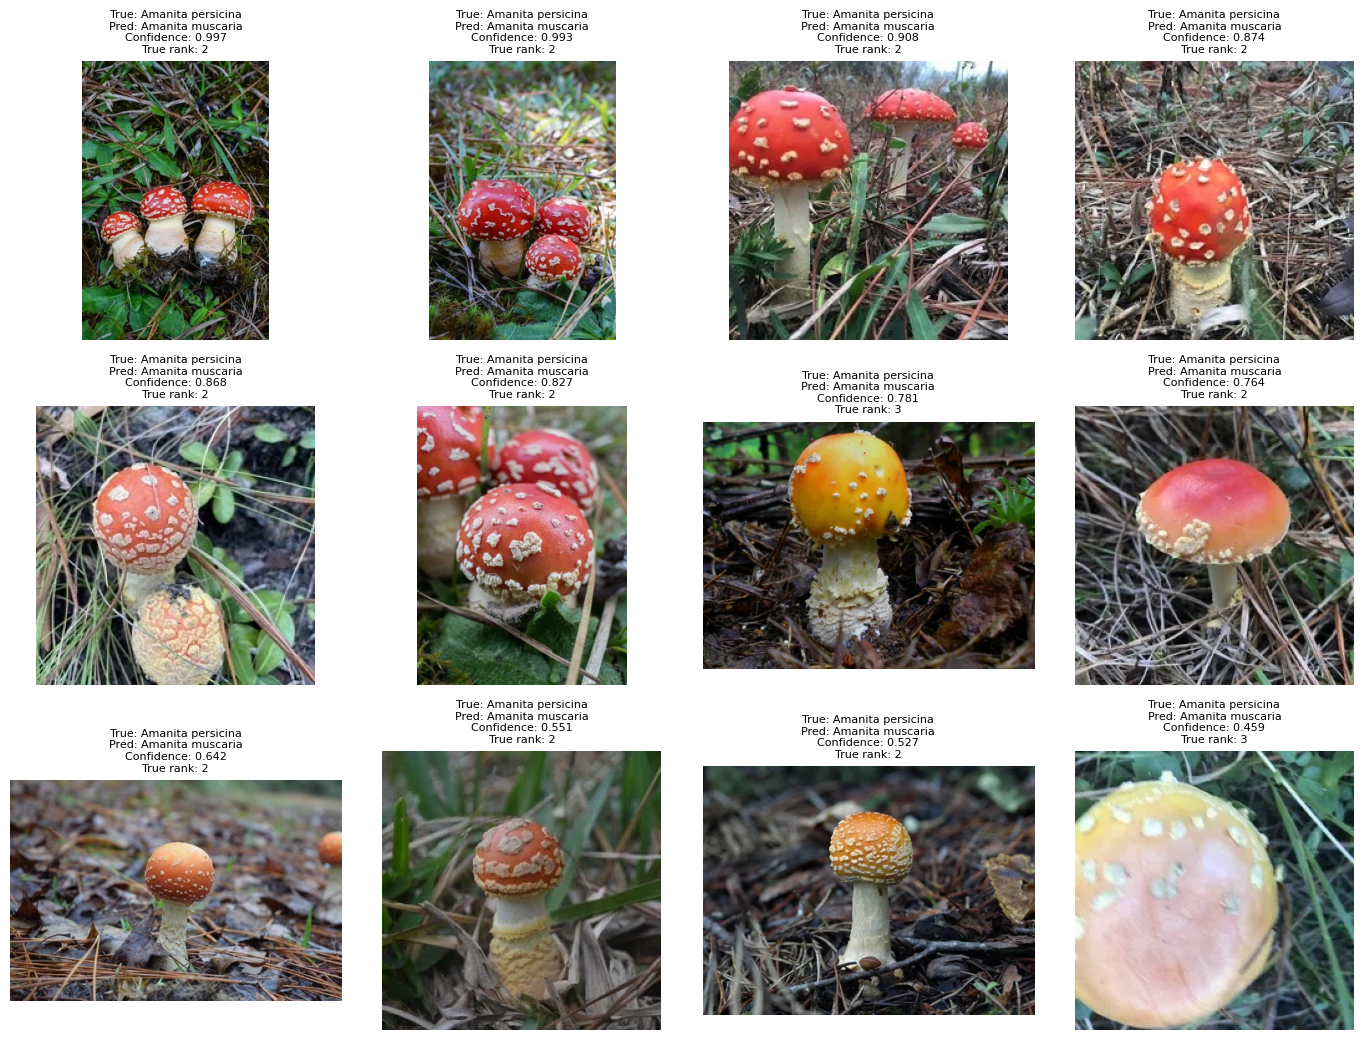

In [73]:
# highest-confidence mistakes for one lookalike pair
plot_confusion_pair(
    true_label="Amanita persicina",
    predicted_label="Amanita muscaria",
    confidence_order="desc"
)

### Diagnostic Findings and Experiment Decisions

* confident wrong lookalikes --> unfreeze final ResNet block
* zero f1-classes --> class weighting or more epochs
* f1 correlation with image count --> imbalance matters
* scattered incorrect predictions --> class not learned yet
* obscured and tiny mushrooms in photos --> targeted quality audit

---

## CNN Experiment Preparation

### Experiment Helpers

In [74]:
# unfreeze layer4 and the final classifier
def unfreeze_layer4_train_fc(model):
    # freeze all model parameters
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze the deepest ResNet18 block
    for param in model.layer4.parameters():
        param.requires_grad = True

    # unfreeze the final classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

---

## CNN Experiments

### Experiment 1: Extended Frozen-Backbone Training

The one-epoch baseline may not provide enough training time for the newly initialized 555-class final layer. This experiment continues the same frozen-backbone configuration for up to five total epochs.

Only the final classification layer remains trainable. Validation macro-F1 is the primary model-selection metric because each mushroom class contributes equally. Validation loss breaks near-ties in macro-F1, and early stopping prevents unnecessary additional epochs.

In [75]:
# experiment 1 cache files
frozen_checkpoint_file = Path(
    "baseline_resnet18_frozen_topk_best.pth"
)

frozen_history_file = Path(
    "baseline_resnet18_frozen_topk_history.parquet"
)

# experiment 1 settings
max_epochs = 5
patience = 2
selection_tolerance = 1e-4

frozen_cache_exists = (
    frozen_checkpoint_file.exists()
    and frozen_history_file.exists()
)

In [76]:
# load the completed experiment when its cache exists
if frozen_cache_exists:
    frozen_checkpoint = torch.load(
        frozen_checkpoint_file,
        map_location=device
    )

    # confirm that the saved classes match the dataset
    if (
        frozen_checkpoint["class_to_idx"]
        != image_dataset.class_to_idx
    ):
        raise ValueError(
            "Checkpoint class mapping does not match "
            "the current dataset."
        )

    # rebuild and restore the selected model
    model = build_resnet18_classifier(
        num_classes=num_classes,
        device=device,
        weights=None
    )

    model.load_state_dict(
        frozen_checkpoint["model_state_dict"]
    )

    model = freeze_backbone_train_fc(model)

    # restore the complete per-epoch history
    frozen_history_df = pd.read_parquet(
        frozen_history_file
    )

    print("loaded frozen-backbone experiment")
    print(
        "selected epoch:",
        frozen_checkpoint["best_epoch"]
    )

loaded frozen-backbone experiment
selected epoch: 5


In [77]:
# initialize experiment 1 when no cache exists
if not frozen_cache_exists:
    # keep only the final classifier trainable
    model = freeze_backbone_train_fc(model)

    # begin continuation with a fresh optimizer state
    frozen_optimizer = torch.optim.Adam(
        model.fc.parameters(),
        lr=0.001
    )

    # begin with the completed one-epoch baseline
    frozen_history = [{
        "experiment": "frozen_backbone_fc_only",
        "epoch": 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "val_top_3_accuracy": val_top_3_accuracy,
        "val_top_5_accuracy": val_top_5_accuracy,
        "val_genus_accuracy": val_genus_accuracy,
        "val_same_genus_error_rate": (
            val_same_genus_error_rate
        )
    }]

    # use epoch 1 as the initial selected model
    best_val_macro_f1 = val_macro_f1
    best_val_loss = val_loss
    best_epoch = 1

    best_model_state = copy.deepcopy(
        model.state_dict()
    )

    epochs_without_improvement = 0

In [78]:
# continue frozen-backbone training when not cached
if not frozen_cache_exists:
    for epoch in range(2, max_epochs + 1):
        # train the final classifier for one epoch
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=frozen_optimizer,
            device=device
        )

        # evaluate all validation metrics for this epoch
        epoch_val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            class_index_to_genus_index=(
                class_index_to_genus_index
            ),
            top_k_values=(3, 5)
        )

        # retain metrics from the same epoch
        frozen_history.append({
            "experiment": "frozen_backbone_fc_only",
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": epoch_val_metrics["loss"],
            "val_accuracy": (
                epoch_val_metrics["accuracy"]
            ),
            "val_macro_f1": (
                epoch_val_metrics["macro_f1"]
            ),
            "val_weighted_f1": (
                epoch_val_metrics["weighted_f1"]
            ),
            "val_top_3_accuracy": (
                epoch_val_metrics["top_3_accuracy"]
            ),
            "val_top_5_accuracy": (
                epoch_val_metrics["top_5_accuracy"]
            ),
            "val_genus_accuracy": (
                epoch_val_metrics["genus_accuracy"]
            ),
            "val_same_genus_error_rate": (
                epoch_val_metrics[
                    "same_genus_error_rate"
                ]
            )
        })

        # determine whether macro-F1 improved
        macro_f1_improved = (
            epoch_val_metrics["macro_f1"]
            > best_val_macro_f1
            + selection_tolerance
        )

        macro_f1_tied = (
            abs(
                epoch_val_metrics["macro_f1"]
                - best_val_macro_f1
            )
            <= selection_tolerance
        )

        val_loss_improved = (
            epoch_val_metrics["loss"]
            < best_val_loss
        )

        # use validation loss to break near-ties
        if macro_f1_improved or (
            macro_f1_tied
            and val_loss_improved
        ):
            best_val_macro_f1 = (
                epoch_val_metrics["macro_f1"]
            )

            best_val_loss = (
                epoch_val_metrics["loss"]
            )

            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        print(
            f"epoch {epoch}/{max_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: "
            f"{epoch_val_metrics['loss']:.4f} | "
            f"val macro-F1: "
            f"{epoch_val_metrics['macro_f1']:.4f}"
        )

        # stop after consecutive non-improving epochs
        if epochs_without_improvement >= patience:
            print("early stopping triggered")
            break

In [79]:
# save newly completed experiment 1
if not frozen_cache_exists:
    # restore the selected validation epoch
    model.load_state_dict(
        best_model_state
    )

    # create and save the per-epoch history
    frozen_history_df = pd.DataFrame(
        frozen_history
    )

    frozen_history_df.to_parquet(
        frozen_history_file,
        index=False
    )

    # save the selected model
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_to_idx": image_dataset.class_to_idx,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "best_val_loss": best_val_loss,
            "history": frozen_history,
            "selection_metric": (
                "validation macro-F1"
            ),
            "selection_tolerance": (
                selection_tolerance
            ),
            "tie_breaker": "validation loss"
        },
        frozen_checkpoint_file
    )

    print("saved frozen-backbone experiment")
    print("selected epoch:", best_epoch)

frozen_history_df

,experiment,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top_3_accuracy,val_top_5_accuracy,val_genus_accuracy,val_same_genus_error_rate
0,frozen_backbone_fc_only,1,3.256664,0.338044,2.641843,0.411026,0.232644,0.393127,0.589486,0.661709,0.466498,0.094184
1,frozen_backbone_fc_only,2,2.113964,0.500793,2.540582,0.453876,0.303394,0.442071,0.634382,0.704319,0.512111,0.106634
2,frozen_backbone_fc_only,3,2.061798,0.508616,2.565217,0.449065,0.307089,0.441223,0.631209,0.704421,0.506004,0.103350
3,frozen_backbone_fc_only,4,2.027767,0.515027,2.579876,0.451215,0.311812,0.445141,0.632437,0.703807,0.510132,0.107360
4,frozen_backbone_fc_only,5,2.010570,0.517966,2.551872,0.458413,0.317007,0.453782,0.639636,0.710323,0.517365,0.108850


In [80]:
# evaluate the selected frozen-backbone model
frozen_selected_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    class_index_to_genus_index=(
        class_index_to_genus_index
    ),
    top_k_values=(3, 5)
)

pd.Series(
    frozen_selected_metrics,
    name="value"
).to_frame()

,value
accuracy,0.458413
macro_f1,0.317007
weighted_f1,0.453782
genus_accuracy,0.517365
same_genus_error_rate,0.108850
top_3_accuracy,0.639636
top_5_accuracy,0.710323
loss,2.551872


### Experiment 2: Layer-4 Fine-Tuning

Epoch 3 produced the highest validation macro-F1, indicating a modest improvement across the less-represented classes. However, validation loss increased while training accuracy continued to rise, suggesting increased overconfidence and a widening training-validation gap.

Epoch 2 was retained as the selected fine-tuning duration because it achieved the lower validation loss with less evidence of overfitting. Experiment 3 therefore evaluates weight decay as a regularization strategy under the same two-epoch fine-tuning setup.

In [81]:
# experiment 2 cache files
layer4_checkpoint_file = Path(
    "resnet18_layer4_finetune_epoch2_topk_selected.pth"
)

layer4_history_file = Path(
    "fine_tune_layer4_epoch2_topk_history.parquet"
)

# experiment 2 settings
fine_tune_epochs = 2
fine_tune_lr = 0.0001

layer4_criterion = nn.CrossEntropyLoss()

layer4_cache_exists = (
    layer4_checkpoint_file.exists()
    and layer4_history_file.exists()
)

In [82]:
# load the completed experiment when its cache exists
if layer4_cache_exists:
    layer4_checkpoint = torch.load(
        layer4_checkpoint_file,
        map_location=device
    )

    # confirm that the saved classes match the dataset
    if (
        layer4_checkpoint["class_to_idx"]
        != image_dataset.class_to_idx
    ):
        raise ValueError(
            "Checkpoint class mapping does not match "
            "the current dataset."
        )

    # rebuild and restore the selected model
    model = build_resnet18_classifier(
        num_classes=num_classes,
        device=device,
        weights=None
    )

    model.load_state_dict(
        layer4_checkpoint["model_state_dict"]
    )

    model = unfreeze_layer4_train_fc(
        model
    )

    # restore the complete per-epoch history
    layer4_history_df = pd.read_parquet(
        layer4_history_file
    )

    print("loaded layer4 fine-tuning experiment")
    print(
        "selected epoch:",
        layer4_checkpoint["fine_tune_epoch"]
    )

In [83]:
# initialize experiment 2 when no cache exists
if not layer4_cache_exists:
    # reset shuffled training order
    set_seed()

    train_loader = make_data_loader(
        dataset=train_dataset,
        shuffle=True
    )

    # begin from the selected experiment 1 model
    frozen_checkpoint = torch.load(
        frozen_checkpoint_file,
        map_location=device
    )

    if (
        frozen_checkpoint["class_to_idx"]
        != image_dataset.class_to_idx
    ):
        raise ValueError(
            "Frozen checkpoint class mapping does not "
            "match the current dataset."
        )

    model = build_resnet18_classifier(
        num_classes=num_classes,
        device=device,
        weights=None
    )

    model.load_state_dict(
        frozen_checkpoint["model_state_dict"]
    )

    # train layer4 and the final classifier
    model = unfreeze_layer4_train_fc(
        model
    )

    layer4_optimizer = torch.optim.Adam(
        filter(
            lambda param: param.requires_grad,
            model.parameters()
        ),
        lr=fine_tune_lr
    )

    layer4_history = []

In [84]:
# run the selected two-epoch fine-tuning experiment
if not layer4_cache_exists:
    for epoch in range(1, fine_tune_epochs + 1):
        # update layer4 and the final classifier
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=layer4_criterion,
            optimizer=layer4_optimizer,
            device=device
        )

        # evaluate all validation metrics
        epoch_val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=layer4_criterion,
            device=device,
            class_index_to_genus_index=(
                class_index_to_genus_index
            ),
            top_k_values=(3, 5)
        )

        # retain metrics from the same epoch
        layer4_history.append({
            "experiment": "layer4_finetuning",
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": epoch_val_metrics["loss"],
            "val_accuracy": (
                epoch_val_metrics["accuracy"]
            ),
            "val_macro_f1": (
                epoch_val_metrics["macro_f1"]
            ),
            "val_weighted_f1": (
                epoch_val_metrics["weighted_f1"]
            ),
            "val_top_3_accuracy": (
                epoch_val_metrics["top_3_accuracy"]
            ),
            "val_top_5_accuracy": (
                epoch_val_metrics["top_5_accuracy"]
            ),
            "val_genus_accuracy": (
                epoch_val_metrics["genus_accuracy"]
            ),
            "val_same_genus_error_rate": (
                epoch_val_metrics[
                    "same_genus_error_rate"
                ]
            ),
            "learning_rate": fine_tune_lr
        })

        print(
            f"epoch {epoch}/{fine_tune_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: "
            f"{epoch_val_metrics['loss']:.4f} | "
            f"val macro-F1: "
            f"{epoch_val_metrics['macro_f1']:.4f}"
        )

epoch 1/2 | train loss: 1.5785 | val loss: 1.6039 | val macro-F1: 0.4577
epoch 2/2 | train loss: 0.9548 | val loss: 1.5683 | val macro-F1: 0.4759


In [85]:
# save newly completed experiment 2
if not layer4_cache_exists:
    # create and save the per-epoch history
    layer4_history_df = pd.DataFrame(
        layer4_history
    )

    layer4_history_df.to_parquet(
        layer4_history_file,
        index=False
    )

    # save the model produced after epoch 2
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_to_idx": image_dataset.class_to_idx,
            "fine_tune_epoch": fine_tune_epochs,
            "history": layer4_history,
            "learning_rate": fine_tune_lr,
            "model": (
                "ResNet18 pretrained, layer4 and "
                "final classifier fine-tuned"
            ),
            "selection_reason": (
                "Epoch 2 retained because epoch 3 "
                "previously increased validation loss "
                "and the train-validation gap."
            )
        },
        layer4_checkpoint_file
    )

    print("saved layer4 fine-tuning experiment")
    print("selected epoch:", fine_tune_epochs)

layer4_history_df

saved layer4 fine-tuning experiment
selected epoch: 2


,experiment,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top_3_accuracy,val_top_5_accuracy,val_genus_accuracy,val_same_genus_error_rate,learning_rate
0,layer4_finetuning,1,1.578483,0.597184,1.603917,0.601972,0.457682,0.595915,0.779885,0.838974,0.664506,0.157110,0.0001
1,layer4_finetuning,2,0.954810,0.737219,1.568291,0.618211,0.475854,0.616165,0.796227,0.852586,0.679483,0.160486,0.0001


In [86]:
# evaluate the selected layer4 fine-tuned model
layer4_selected_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=layer4_criterion,
    device=device,
    class_index_to_genus_index=(
        class_index_to_genus_index
    ),
    top_k_values=(3, 5)
)

pd.Series(
    layer4_selected_metrics,
    name="value"
).to_frame()

,value
accuracy,0.618211
macro_f1,0.475854
weighted_f1,0.616165
genus_accuracy,0.679483
same_genus_error_rate,0.160486
top_3_accuracy,0.796227
top_5_accuracy,0.852586
loss,1.568291


* Fine-tuning began to show overfitting signs by epoch 3 because validation loss increased while training accuracy rose sharply.
* Macro F1 has best performance on third epoch, which is better for the minor classes
* However, epoch two did the best here since the priority is lowest validation loss/less-overconfidence
* Further training should use regularization, lower learning rate, or early stopping.

### Experiment 3: Weight Decay

Layer-4 fine-tuning increased model flexibility but also increased the risk of overfitting. This experiment repeats the same Layer-4 fine-tuning setup while adding L2-style weight decay through the Adam optimizer.

The experiment starts from the same selected frozen-backbone checkpoint as Experiment 2. The learning rate, trainable layers, data split, loss function, and training duration remain unchanged so the effect of weight decay can be evaluated directly.

In [87]:
# experiment 3 cache files
weight_decay_checkpoint_file = Path(
    "resnet18_layer4_weight_decay_topk_selected.pth"
)

weight_decay_history_file = Path(
    "layer4_weight_decay_topk_history.parquet"
)


# experiment 3 settings
weight_decay_epochs = 2
weight_decay_lr = 0.0001
weight_decay_value = 0.0001
weight_decay_selection_tolerance = 1e-4

weight_decay_criterion = nn.CrossEntropyLoss()

weight_decay_cache_exists = (
    weight_decay_checkpoint_file.exists()
    and weight_decay_history_file.exists()
)

In [88]:
# load the completed experiment when its cache exists
if weight_decay_cache_exists:
    weight_decay_checkpoint = torch.load(
        weight_decay_checkpoint_file,
        map_location=device
    )

    # confirm that the saved classes match the dataset
    if (
        weight_decay_checkpoint["class_to_idx"]
        != image_dataset.class_to_idx
    ):
        raise ValueError(
            "Checkpoint class mapping does not match "
            "the current dataset."
        )

    # rebuild and restore the selected model
    weight_decay_model = (
        build_resnet18_classifier(
            num_classes=num_classes,
            device=device,
            weights=None
        )
    )

    weight_decay_model.load_state_dict(
        weight_decay_checkpoint[
            "model_state_dict"
        ]
    )

    weight_decay_model = (
        unfreeze_layer4_train_fc(
            weight_decay_model
        )
    )

    # restore the complete per-epoch history
    weight_decay_history_df = pd.read_parquet(
        weight_decay_history_file
    )

    print("loaded weight-decay experiment")
    print(
        "selected epoch:",
        weight_decay_checkpoint["best_epoch"]
    )

In [89]:
# initialize experiment 3 when no cache exists
if not weight_decay_cache_exists:
    # reset shuffled training order
    set_seed()

    train_loader = make_data_loader(
        dataset=train_dataset,
        shuffle=True
    )

    # begin from the selected experiment 1 model
    frozen_checkpoint = torch.load(
        frozen_checkpoint_file,
        map_location=device
    )

    if (
        frozen_checkpoint["class_to_idx"]
        != image_dataset.class_to_idx
    ):
        raise ValueError(
            "Frozen checkpoint class mapping does not "
            "match the current dataset."
        )

    weight_decay_model = (
        build_resnet18_classifier(
            num_classes=num_classes,
            device=device,
            weights=None
        )
    )

    weight_decay_model.load_state_dict(
        frozen_checkpoint[
            "model_state_dict"
        ]
    )

    # train layer4 and the final classifier
    weight_decay_model = (
        unfreeze_layer4_train_fc(
            weight_decay_model
        )
    )

    # add weight decay to the experiment 2 optimizer
    weight_decay_optimizer = torch.optim.Adam(
        filter(
            lambda param: param.requires_grad,
            weight_decay_model.parameters()
        ),
        lr=weight_decay_lr,
        weight_decay=weight_decay_value
    )

    weight_decay_history = []

    best_weight_decay_state = None
    best_weight_decay_epoch = None
    best_weight_decay_macro_f1 = -np.inf
    best_weight_decay_val_loss = np.inf

In [90]:
# run the layer4 weight-decay experiment
if not weight_decay_cache_exists:
    for epoch in range(
        1,
        weight_decay_epochs + 1
    ):
        # update layer4 and the final classifier
        train_loss, train_accuracy = (
            train_one_epoch(
                model=weight_decay_model,
                loader=train_loader,
                criterion=weight_decay_criterion,
                optimizer=weight_decay_optimizer,
                device=device
            )
        )

        # evaluate all validation metrics
        epoch_val_metrics = evaluate_model(
            model=weight_decay_model,
            loader=val_loader,
            criterion=weight_decay_criterion,
            device=device,
            class_index_to_genus_index=(
                class_index_to_genus_index
            ),
            top_k_values=(3, 5)
        )

        # retain metrics from the same epoch
        weight_decay_history.append({
            "experiment": "layer4_weight_decay",
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": (
                epoch_val_metrics["loss"]
            ),
            "val_accuracy": (
                epoch_val_metrics["accuracy"]
            ),
            "val_macro_f1": (
                epoch_val_metrics["macro_f1"]
            ),
            "val_weighted_f1": (
                epoch_val_metrics["weighted_f1"]
            ),
            "val_top_3_accuracy": (
                epoch_val_metrics[
                    "top_3_accuracy"
                ]
            ),
            "val_top_5_accuracy": (
                epoch_val_metrics[
                    "top_5_accuracy"
                ]
            ),
            "val_genus_accuracy": (
                epoch_val_metrics[
                    "genus_accuracy"
                ]
            ),
            "val_same_genus_error_rate": (
                epoch_val_metrics[
                    "same_genus_error_rate"
                ]
            ),
            "learning_rate": weight_decay_lr,
            "weight_decay": weight_decay_value
        })

        # determine whether macro-F1 improved
        macro_f1_improved = (
            epoch_val_metrics["macro_f1"]
            > best_weight_decay_macro_f1
            + weight_decay_selection_tolerance
        )

        macro_f1_tied = (
            abs(
                epoch_val_metrics["macro_f1"]
                - best_weight_decay_macro_f1
            )
            <= weight_decay_selection_tolerance
        )

        val_loss_improved = (
            epoch_val_metrics["loss"]
            < best_weight_decay_val_loss
        )

        # use validation loss to break near-ties
        if macro_f1_improved or (
            macro_f1_tied
            and val_loss_improved
        ):
            best_weight_decay_state = (
                copy.deepcopy(
                    weight_decay_model.state_dict()
                )
            )

            best_weight_decay_epoch = epoch

            best_weight_decay_macro_f1 = (
                epoch_val_metrics["macro_f1"]
            )

            best_weight_decay_val_loss = (
                epoch_val_metrics["loss"]
            )

        print(
            f"epoch {epoch}/{weight_decay_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: "
            f"{epoch_val_metrics['loss']:.4f} | "
            f"val macro-F1: "
            f"{epoch_val_metrics['macro_f1']:.4f}"
        )

epoch 1/2 | train loss: 1.5751 | val loss: 1.5923 | val macro-F1: 0.4590
epoch 2/2 | train loss: 0.9604 | val loss: 1.5563 | val macro-F1: 0.4763


In [91]:
# save newly completed experiment 3
if not weight_decay_cache_exists:
    # restore the selected validation epoch
    weight_decay_model.load_state_dict(
        best_weight_decay_state
    )

    # create and save the per-epoch history
    weight_decay_history_df = pd.DataFrame(
        weight_decay_history
    )

    weight_decay_history_df.to_parquet(
        weight_decay_history_file,
        index=False
    )

    # save the selected model
    torch.save(
        {
            "model_state_dict": (
                weight_decay_model.state_dict()
            ),
            "class_to_idx": (
                image_dataset.class_to_idx
            ),
            "best_epoch": (
                best_weight_decay_epoch
            ),
            "best_val_macro_f1": (
                best_weight_decay_macro_f1
            ),
            "best_val_loss": (
                best_weight_decay_val_loss
            ),
            "history": weight_decay_history,
            "learning_rate": weight_decay_lr,
            "weight_decay": weight_decay_value,
            "selection_metric": (
                "validation macro-F1"
            ),
            "selection_tolerance": (
                weight_decay_selection_tolerance
            ),
            "tie_breaker": "validation loss",
            "model": (
                "ResNet18 pretrained, layer4 and "
                "final classifier fine-tuned with "
                "weight decay"
            )
        },
        weight_decay_checkpoint_file
    )

    print("saved weight-decay experiment")
    print(
        "selected epoch:",
        best_weight_decay_epoch
    )

weight_decay_history_df

saved weight-decay experiment
selected epoch: 2


,experiment,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top_3_accuracy,val_top_5_accuracy,val_genus_accuracy,val_same_genus_error_rate,learning_rate,weight_decay
0,layer4_weight_decay,1,1.575070,0.597966,1.592327,0.603644,0.458965,0.597606,0.782922,0.838019,0.666075,0.157514,0.0001,0.0001
1,layer4_weight_decay,2,0.960395,0.735516,1.556270,0.618620,0.476266,0.616293,0.795476,0.851767,0.679449,0.159495,0.0001,0.0001


In [92]:
# evaluate the selected weight-decay model
weight_decay_selected_metrics = evaluate_model(
    model=weight_decay_model,
    loader=val_loader,
    criterion=weight_decay_criterion,
    device=device,
    class_index_to_genus_index=(
        class_index_to_genus_index
    ),
    top_k_values=(3, 5)
)

pd.Series(
    weight_decay_selected_metrics,
    name="value"
).to_frame()

,value
accuracy,0.618620
macro_f1,0.476266
weighted_f1,0.616293
genus_accuracy,0.679449
same_genus_error_rate,0.159495
top_3_accuracy,0.795476
top_5_accuracy,0.851767
loss,1.556270


---

## CNN Experiment Comparison and Model Selection

The selected result from each CNN experiment is compared using the same validation metrics. Validation macro-F1 remains the primary model-selection metric because each mushroom class contributes equally. Validation loss is used to break near-ties.

Top-3 accuracy, top-5 accuracy, and genus-level accuracy are retained as supplementary measures of practical identification performance.

In [93]:
# collect the selected validation results from each experiment
cnn_comparison_df = pd.DataFrame([
    {
        "model": "Extended frozen backbone",
        "checkpoint_file": str(
            frozen_checkpoint_file
        ),
        "val_loss": frozen_selected_metrics["loss"],
        "val_accuracy": (
            frozen_selected_metrics["accuracy"]
        ),
        "val_macro_f1": (
            frozen_selected_metrics["macro_f1"]
        ),
        "val_weighted_f1": (
            frozen_selected_metrics["weighted_f1"]
        ),
        "val_top_3_accuracy": (
            frozen_selected_metrics["top_3_accuracy"]
        ),
        "val_top_5_accuracy": (
            frozen_selected_metrics["top_5_accuracy"]
        ),
        "val_genus_accuracy": (
            frozen_selected_metrics["genus_accuracy"]
        ),
        "val_same_genus_error_rate": (
            frozen_selected_metrics[
                "same_genus_error_rate"
            ]
        )
    },
    {
        "model": "Layer4 fine-tuning",
        "checkpoint_file": str(
            layer4_checkpoint_file
        ),
        "val_loss": layer4_selected_metrics["loss"],
        "val_accuracy": (
            layer4_selected_metrics["accuracy"]
        ),
        "val_macro_f1": (
            layer4_selected_metrics["macro_f1"]
        ),
        "val_weighted_f1": (
            layer4_selected_metrics["weighted_f1"]
        ),
        "val_top_3_accuracy": (
            layer4_selected_metrics["top_3_accuracy"]
        ),
        "val_top_5_accuracy": (
            layer4_selected_metrics["top_5_accuracy"]
        ),
        "val_genus_accuracy": (
            layer4_selected_metrics["genus_accuracy"]
        ),
        "val_same_genus_error_rate": (
            layer4_selected_metrics[
                "same_genus_error_rate"
            ]
        )
    },
    {
        "model": "Layer4 with weight decay",
        "checkpoint_file": str(
            weight_decay_checkpoint_file
        ),
        "val_loss": (
            weight_decay_selected_metrics["loss"]
        ),
        "val_accuracy": (
            weight_decay_selected_metrics["accuracy"]
        ),
        "val_macro_f1": (
            weight_decay_selected_metrics["macro_f1"]
        ),
        "val_weighted_f1": (
            weight_decay_selected_metrics[
                "weighted_f1"
            ]
        ),
        "val_top_3_accuracy": (
            weight_decay_selected_metrics[
                "top_3_accuracy"
            ]
        ),
        "val_top_5_accuracy": (
            weight_decay_selected_metrics[
                "top_5_accuracy"
            ]
        ),
        "val_genus_accuracy": (
            weight_decay_selected_metrics[
                "genus_accuracy"
            ]
        ),
        "val_same_genus_error_rate": (
            weight_decay_selected_metrics[
                "same_genus_error_rate"
            ]
        )
    }
])

# rank the experiments by the primary selection metric
cnn_comparison_df.sort_values(
    [
        "val_macro_f1",
        "val_loss"
    ],
    ascending=[False, True]
).reset_index(drop=True)

,model,checkpoint_file,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top_3_accuracy,val_top_5_accuracy,val_genus_accuracy,val_same_genus_error_rate
0,Layer4 with weight decay,resnet18_layer4_weight_decay_topk_selected.pth,1.556270,0.618620,0.476266,0.616293,0.795476,0.851767,0.679449,0.159495
1,Layer4 fine-tuning,resnet18_layer4_finetune_epoch2_topk_selected.pth,1.568291,0.618211,0.475854,0.616165,0.796227,0.852586,0.679483,0.160486
2,Extended frozen backbone,baseline_resnet18_frozen_topk_best.pth,2.551872,0.458413,0.317007,0.453782,0.639636,0.710323,0.517365,0.108850


In [94]:
# define the tolerance used for near-ties in macro-F1
cnn_selection_tolerance = 1e-4

# identify the highest validation macro-F1
best_cnn_macro_f1 = (
    cnn_comparison_df["val_macro_f1"].max()
)

# retain models within tolerance of the highest macro-F1
cnn_selection_candidates = cnn_comparison_df[
    cnn_comparison_df["val_macro_f1"]
    >= best_cnn_macro_f1
    - cnn_selection_tolerance
].copy()

# use validation loss to break a near-tie
selected_cnn_row = (
    cnn_selection_candidates
    .sort_values(
        [
            "val_loss",
            "model"
        ]
    )
    .iloc[0]
)

selected_cnn_name = selected_cnn_row["model"]

selected_cnn_checkpoint_file = Path(
    selected_cnn_row["checkpoint_file"]
)

print("selected CNN:", selected_cnn_name)
print(
    "validation macro-F1:",
    selected_cnn_row["val_macro_f1"]
)
print(
    "validation loss:",
    selected_cnn_row["val_loss"]
)
print(
    "checkpoint:",
    selected_cnn_checkpoint_file
)

selected CNN: Layer4 with weight decay
validation macro-F1: 0.47626552307396725
validation loss: 1.5562700709271118
checkpoint: resnet18_layer4_weight_decay_topk_selected.pth


In [95]:
# load the selected CNN checkpoint
selected_cnn_checkpoint = torch.load(
    selected_cnn_checkpoint_file,
    map_location=device
)

# confirm that the saved classes match the dataset
if (
    selected_cnn_checkpoint["class_to_idx"]
    != image_dataset.class_to_idx
):
    raise ValueError(
        "Selected checkpoint class mapping does not "
        "match the current dataset."
    )

# rebuild and restore the selected classifier
selected_cnn_model = build_resnet18_classifier(
    num_classes=num_classes,
    device=device,
    weights=None
)

selected_cnn_model.load_state_dict(
    selected_cnn_checkpoint["model_state_dict"]
)

# disable parameter updates for downstream feature extraction
for param in selected_cnn_model.parameters():
    param.requires_grad = False

selected_cnn_model.eval()

print("restored selected CNN:", selected_cnn_name)

restored selected CNN: Layer4 with weight decay


### Cross-Experiment Training Curves

The following figures compare the training trajectories of the three CNN experiments.

Color identifies the experiment, while line style identifies the metric. Epoch numbers are local to each experiment rather than one continuous training timeline. Experiments 2 and 3 both begin from the selected Experiment 1 checkpoint.

In [96]:
# combine the CNN experiment histories
cnn_history_df = pd.concat(
    [
        frozen_history_df.assign(
            model="Extended frozen backbone"
        ),
        layer4_history_df.assign(
            model="Layer4 fine-tuning"
        ),
        weight_decay_history_df.assign(
            model="Layer4 with weight decay"
        )
    ],
    ignore_index=True
)

# use one color for each experiment
cnn_experiment_colors = {
    "Extended frozen backbone": "tab:blue",
    "Layer4 fine-tuning": "tab:orange",
    "Layer4 with weight decay": "tab:green"
}

cnn_history_df

,experiment,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top_3_accuracy,val_top_5_accuracy,val_genus_accuracy,val_same_genus_error_rate,model,learning_rate,weight_decay
0,frozen_backbone_fc_only,1,3.256664,0.338044,2.641843,0.411026,0.232644,0.393127,0.589486,0.661709,0.466498,0.094184,Extended frozen backbone,NaN,NaN
1,frozen_backbone_fc_only,2,2.113964,0.500793,2.540582,0.453876,0.303394,0.442071,0.634382,0.704319,0.512111,0.106634,Extended frozen backbone,NaN,NaN
2,frozen_backbone_fc_only,3,2.061798,0.508616,2.565217,0.449065,0.307089,0.441223,0.631209,0.704421,0.506004,0.103350,Extended frozen backbone,NaN,NaN
3,frozen_backbone_fc_only,4,2.027767,0.515027,2.579876,0.451215,0.311812,0.445141,0.632437,0.703807,0.510132,0.107360,Extended frozen backbone,NaN,NaN
4,frozen_backbone_fc_only,5,2.010570,0.517966,2.551872,0.458413,0.317007,0.453782,0.639636,0.710323,0.517365,0.108850,Extended frozen backbone,NaN,NaN
5,layer4_finetuning,1,1.578483,0.597184,1.603917,0.601972,0.457682,0.595915,0.779885,0.838974,0.664506,0.157110,Layer4 fine-tuning,0.0001,NaN
6,layer4_finetuning,2,0.954810,0.737219,1.568291,0.618211,0.475854,0.616165,0.796227,0.852586,0.679483,0.160486,Layer4 fine-tuning,0.0001,NaN
7,layer4_weight_decay,1,1.575070,0.597966,1.592327,0.603644,0.458965,0.597606,0.782922,0.838019,0.666075,0.157514,Layer4 with weight decay,0.0001,0.0001
8,layer4_weight_decay,2,0.960395,0.735516,1.556270,0.618620,0.476266,0.616293,0.795476,0.851767,0.679449,0.159495,Layer4 with weight decay,0.0001,0.0001


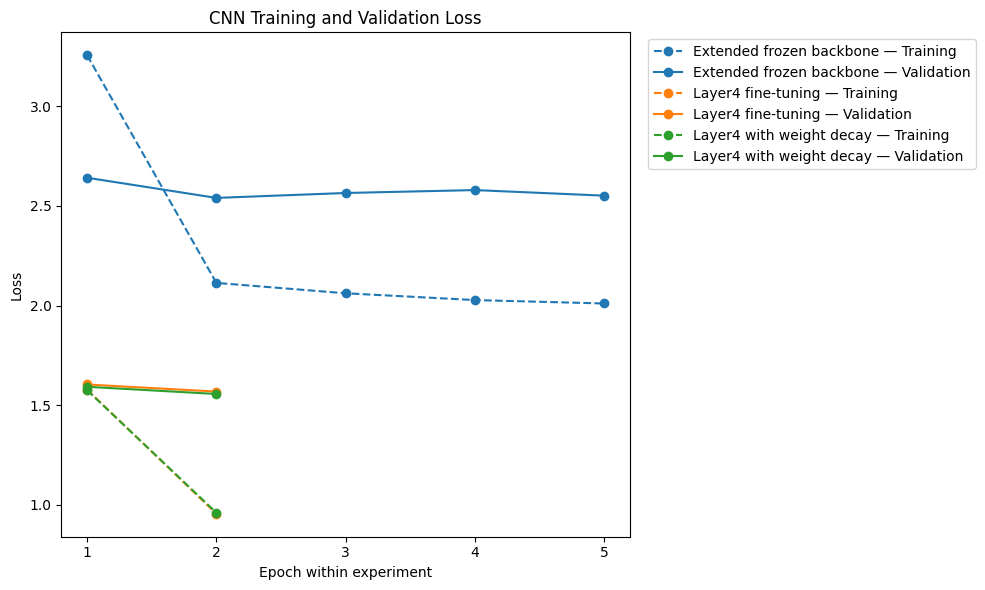

In [97]:
# compare training and validation loss across experiments
plt.figure(figsize=(10, 6))

for model_name, color in cnn_experiment_colors.items():
    model_history = (
        cnn_history_df[
            cnn_history_df["model"] == model_name
        ]
        .sort_values("epoch")
    )

    plt.plot(
        model_history["epoch"],
        model_history["train_loss"],
        marker="o",
        linestyle="--",
        color=color,
        label=f"{model_name} — Training"
    )

    plt.plot(
        model_history["epoch"],
        model_history["val_loss"],
        marker="o",
        linestyle="-",
        color=color,
        label=f"{model_name} — Validation"
    )

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch within experiment")
plt.ylabel("Loss")
plt.xticks(
    sorted(cnn_history_df["epoch"].unique())
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

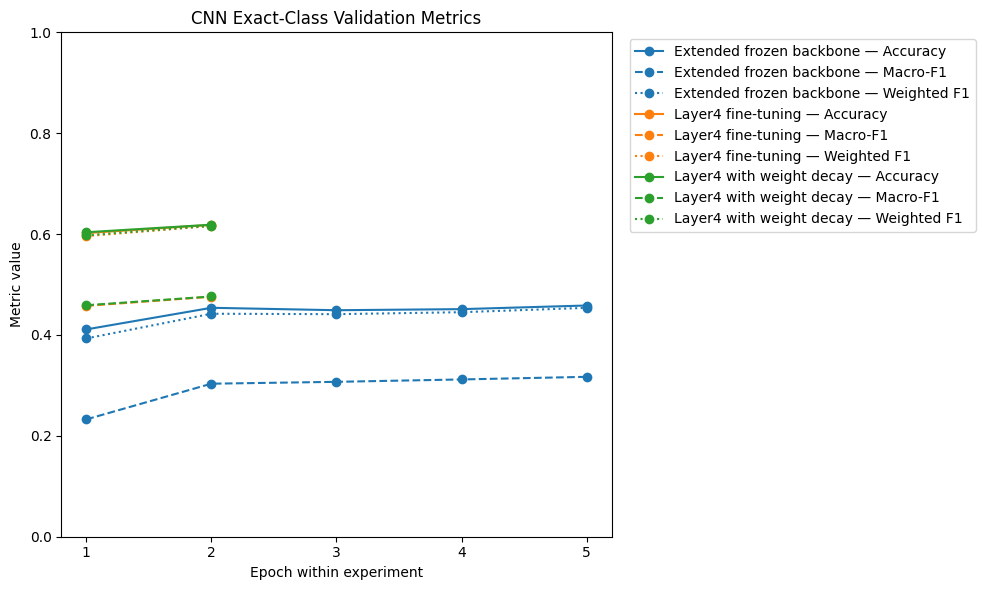

In [98]:
# compare exact-class validation metrics
exact_class_metrics = {
    "val_accuracy": (
        "Accuracy",
        "-"
    ),
    "val_macro_f1": (
        "Macro-F1",
        "--"
    ),
    "val_weighted_f1": (
        "Weighted F1",
        ":"
    )
}

plt.figure(figsize=(10, 6))

for model_name, color in cnn_experiment_colors.items():
    model_history = (
        cnn_history_df[
            cnn_history_df["model"] == model_name
        ]
        .sort_values("epoch")
    )

    for column, (
        metric_label,
        line_style
    ) in exact_class_metrics.items():
        plt.plot(
            model_history["epoch"],
            model_history[column],
            marker="o",
            linestyle=line_style,
            color=color,
            label=(
                f"{model_name} — "
                f"{metric_label}"
            )
        )

plt.title(
    "CNN Exact-Class Validation Metrics"
)
plt.xlabel("Epoch within experiment")
plt.ylabel("Metric value")
plt.xticks(
    sorted(cnn_history_df["epoch"].unique())
)
plt.ylim(0, 1)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

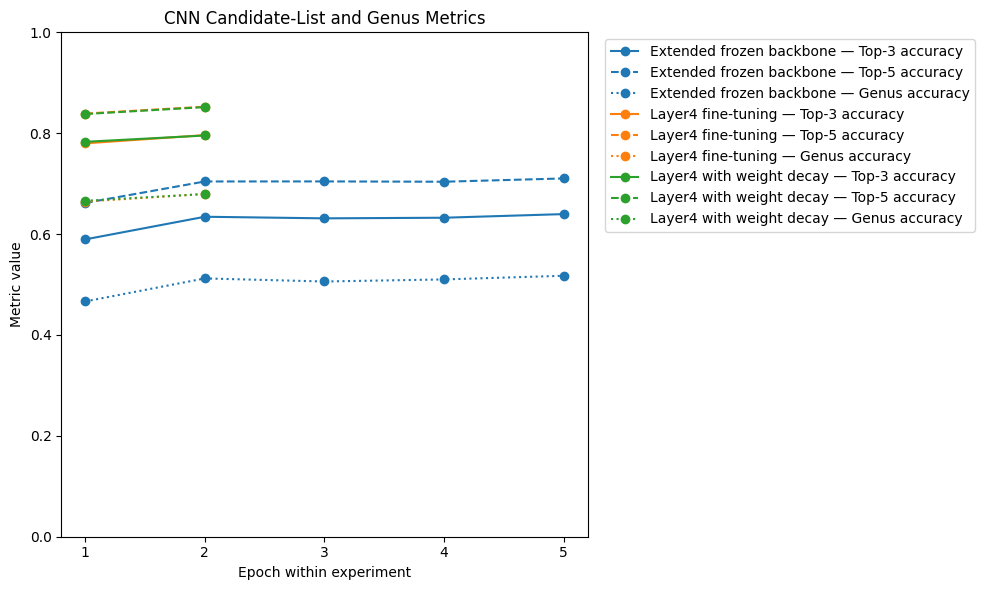

In [99]:
# compare candidate-list and genus validation metrics
candidate_metrics = {
    "val_top_3_accuracy": (
        "Top-3 accuracy",
        "-"
    ),
    "val_top_5_accuracy": (
        "Top-5 accuracy",
        "--"
    ),
    "val_genus_accuracy": (
        "Genus accuracy",
        ":"
    )
}

plt.figure(figsize=(10, 6))

for model_name, color in cnn_experiment_colors.items():
    model_history = (
        cnn_history_df[
            cnn_history_df["model"] == model_name
        ]
        .sort_values("epoch")
    )

    for column, (
        metric_label,
        line_style
    ) in candidate_metrics.items():
        plt.plot(
            model_history["epoch"],
            model_history[column],
            marker="o",
            linestyle=line_style,
            color=color,
            label=(
                f"{model_name} — "
                f"{metric_label}"
            )
        )

plt.title(
    "CNN Candidate-List and Genus Metrics"
)
plt.xlabel("Epoch within experiment")
plt.ylabel("Metric value")
plt.xticks(
    sorted(cnn_history_df["epoch"].unique())
)
plt.ylim(0, 1)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

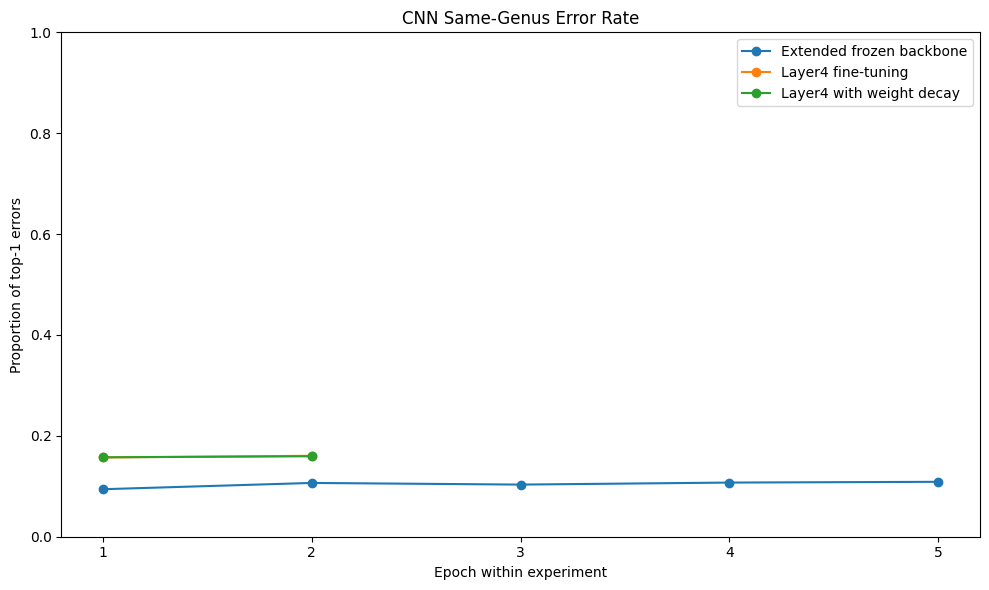

In [100]:
# compare the proportion of top-1 errors within genus
plt.figure(figsize=(10, 6))

for model_name, color in cnn_experiment_colors.items():
    model_history = (
        cnn_history_df[
            cnn_history_df["model"] == model_name
        ]
        .sort_values("epoch")
    )

    plt.plot(
        model_history["epoch"],
        model_history[
            "val_same_genus_error_rate"
        ],
        marker="o",
        color=color,
        label=model_name
    )

plt.title(
    "CNN Same-Genus Error Rate"
)
plt.xlabel("Epoch within experiment")
plt.ylabel(
    "Proportion of top-1 errors"
)
plt.xticks(
    sorted(cnn_history_df["epoch"].unique())
)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

---

## Selected CNN Embedding Preparation

The selected CNN is used as a fixed feature extractor by removing its final 555-class classification layer. Each image is represented by the resulting 512-dimensional embedding.

Traditional supervised models are trained using only the training embeddings and compared using validation embeddings. Test embeddings remain untouched until final model selection.

### Selected CNN Feature Extractor

In [101]:
# copy the selected CNN for embedding extraction
selected_feature_extractor = copy.deepcopy(
    selected_cnn_model
)

# replace the final classifier with an identity operation
selected_feature_extractor.fc = nn.Identity()

# disable parameter updates during feature extraction
for param in selected_feature_extractor.parameters():
    param.requires_grad = False

selected_feature_extractor = (
    selected_feature_extractor.to(device)
)

selected_feature_extractor.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Deterministic Embedding Datasets

In [102]:
# use the deterministic evaluation transform for embedding extraction
embedding_train_dataset = Subset(
    image_dataset,
    train_indices
)

embedding_val_dataset = Subset(
    image_dataset,
    val_indices
)

print(
    "training images:",
    len(embedding_train_dataset)
)

print(
    "validation images:",
    len(embedding_val_dataset)
)

training images: 136787
validation images: 29312


### Embedding Extraction and Cache

In [103]:
# define the selected-model embedding cache
selected_embedding_file = Path(
    "selected_cnn_train_val_embeddings.pth"
)

selected_checkpoint_name = (
    selected_cnn_checkpoint_file.name
)

# inspect an existing cache before deciding whether to reuse it
embedding_cache_is_current = False

if selected_embedding_file.exists():
    selected_embedding_data = torch.load(
        selected_embedding_file,
        map_location="cpu"
    )

    embedding_cache_is_current = (
        selected_embedding_data["class_to_idx"]
        == image_dataset.class_to_idx
        and selected_embedding_data["checkpoint_file"]
        == selected_checkpoint_name
    )

# load embeddings produced by the currently selected CNN
if embedding_cache_is_current:
    train_embeddings = selected_embedding_data[
        "train_embeddings"
    ]

    train_embedding_labels = selected_embedding_data[
        "train_labels"
    ]

    val_embeddings = selected_embedding_data[
        "val_embeddings"
    ]

    val_embedding_labels = selected_embedding_data[
        "val_labels"
    ]

    print(
        "loaded selected CNN embeddings:",
        selected_embedding_file
    )

# otherwise extract and save new embeddings
else:
    train_embeddings, train_embedding_labels = (
        extract_image_embeddings(
            feature_extractor=selected_feature_extractor,
            image_dataset=embedding_train_dataset,
            batch_size=64
        )
    )

    val_embeddings, val_embedding_labels = (
        extract_image_embeddings(
            feature_extractor=selected_feature_extractor,
            image_dataset=embedding_val_dataset,
            batch_size=64
        )
    )

    torch.save(
        {
            "train_embeddings": train_embeddings,
            "train_labels": train_embedding_labels,
            "val_embeddings": val_embeddings,
            "val_labels": val_embedding_labels,
            "class_to_idx": image_dataset.class_to_idx,
            "checkpoint_file": selected_checkpoint_name,
            "selected_cnn": selected_cnn_name,
            "seed": SEED,
            "embedding_dimension": 512
        },
        selected_embedding_file
    )

    print(
        "created selected CNN embeddings:",
        selected_embedding_file
    )

created selected CNN embeddings: selected_cnn_train_val_embeddings.pth


### Embedding Split Preparation

In [104]:
# convert embedding tensors into sklearn-compatible arrays
X_train_embeddings = train_embeddings.numpy()
y_train_embeddings = train_embedding_labels.numpy()

X_val_embeddings = val_embeddings.numpy()
y_val_embeddings = val_embedding_labels.numpy()

print(
    "training predictors:",
    X_train_embeddings.shape
)

print(
    "validation predictors:",
    X_val_embeddings.shape
)

training predictors: (136787, 512)
validation predictors: (29312, 512)


### Model-Specific Feature Transformations

In [105]:
# normalize embeddings for similarity and linear models
X_train_linear = normalize(
    X_train_embeddings
)

X_val_linear = normalize(
    X_val_embeddings
)

# preserve original embeddings for the tree-based model
X_train_tree = X_train_embeddings
X_val_tree = X_val_embeddings

# use the same class labels for every baseline model
y_train = y_train_embeddings
y_val = y_val_embeddings

print(
    "linear-model predictors:",
    X_train_linear.shape
)

print(
    "tree-model predictors:",
    X_train_tree.shape
)

linear-model predictors: (136787, 512)
tree-model predictors: (136787, 512)


---

## Traditional Baseline Models

The following traditional classifiers use the selected CNN embeddings as predictors rather than operating directly on the mushroom images.

Logistic Regression and Linear SVM provide linear classification baselines. Random Forest provides a nonlinear tree-based baseline.

All models are trained using the training embeddings and evaluated using the validation embeddings. These models are included as baseline comparisons and are not extensively tuned.

In [106]:
# identify caches produced from the selected CNN
baseline_cache_tag = (
    selected_cnn_checkpoint_file.stem
)

### Logistic Regression

In [107]:
# load or train the logistic regression baseline
lr_cache = Path(
    f"logreg_{baseline_cache_tag}.pkl"
)

if lr_cache.exists():
    with lr_cache.open("rb") as file:
        logreg = pickle.load(file)

    print("loaded logistic regression")

else:
    logreg = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    logreg.fit(
        X_train_linear,
        y_train
    )

    with lr_cache.open("wb") as file:
        pickle.dump(logreg, file)

    print("trained and saved logistic regression")

trained and saved logistic regression


In [108]:
# evaluate on validation embeddings
lr_val_predictions = logreg.predict(
    X_val_linear
)

lr_val_accuracy = accuracy_score(
    y_val,
    lr_val_predictions
)

lr_val_macro_f1 = f1_score(
    y_val,
    lr_val_predictions,
    average="macro",
    zero_division=0
)

logreg_result = {
    "model": "Logistic Regression",
    "val_accuracy": lr_val_accuracy,
    "val_macro_f1": lr_val_macro_f1
}

pd.Series(
    logreg_result,
    name="value"
).to_frame()

,value
model,Logistic Regression
val_accuracy,0.605793
val_macro_f1,0.351432


### Linear SVM

In [109]:
# load or train the linear SVM baseline
svm_cache = Path(
    f"linear_svm_{baseline_cache_tag}.pkl"
)

if svm_cache.exists():
    with svm_cache.open("rb") as file:
        linear_svm = pickle.load(file)

    print("loaded linear SVM")

else:
    linear_svm = LinearSVC(
        max_iter=2000,
        random_state=SEED
    )

    linear_svm.fit(
        X_train_linear,
        y_train
    )

    with svm_cache.open("wb") as file:
        pickle.dump(linear_svm, file)

    print("trained and saved linear SVM")

trained and saved linear SVM


In [110]:
# evaluate on validation embeddings
svm_val_predictions = linear_svm.predict(
    X_val_linear
)

svm_val_accuracy = accuracy_score(
    y_val,
    svm_val_predictions
)

svm_val_macro_f1 = f1_score(
    y_val,
    svm_val_predictions,
    average="macro",
    zero_division=0
)

svm_result = {
    "model": "Linear SVM",
    "val_accuracy": svm_val_accuracy,
    "val_macro_f1": svm_val_macro_f1
}

pd.Series(
    svm_result,
    name="value"
).to_frame()

,value
model,Linear SVM
val_accuracy,0.634621
val_macro_f1,0.476951


### Random Forest

In [111]:
# load or train the constrained random forest baseline
rf_cache = Path(
    f"random_forest_constrained_{baseline_cache_tag}.pkl"
)

if rf_cache.exists():
    with rf_cache.open("rb") as file:
        random_forest = pickle.load(file)

    print("loaded random forest")

else:
    random_forest = RandomForestClassifier(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=2,
        max_features="sqrt",
        max_samples=0.5,
        random_state=SEED,
        n_jobs=1
    )

    random_forest.fit(
        X_train_tree,
        y_train
    )

    with rf_cache.open("wb") as file:
        pickle.dump(random_forest, file)

    print("trained and saved random forest")

# evaluate on validation embeddings
rf_val_predictions = random_forest.predict(
    X_val_tree
)

rf_val_accuracy = accuracy_score(
    y_val,
    rf_val_predictions
)

rf_val_macro_f1 = f1_score(
    y_val,
    rf_val_predictions,
    average="macro",
    zero_division=0
)

rf_result = {
    "model": "Random Forest",
    "val_accuracy": rf_val_accuracy,
    "val_macro_f1": rf_val_macro_f1
}

pd.Series(
    rf_result,
    name="value"
).to_frame()

trained and saved random forest


,value
model,Random Forest
val_accuracy,0.372441
val_macro_f1,0.15163


In [112]:
# evaluate on validation embeddings
rf_val_predictions = random_forest.predict(
    X_val_tree
)

rf_val_accuracy = accuracy_score(
    y_val,
    rf_val_predictions
)

rf_val_macro_f1 = f1_score(
    y_val,
    rf_val_predictions,
    average="macro",
    zero_division=0
)

rf_result = {
    "model": "Random Forest",
    "val_accuracy": rf_val_accuracy,
    "val_macro_f1": rf_val_macro_f1
}

pd.Series(
    rf_result,
    name="value"
).to_frame()

,value
model,Random Forest
val_accuracy,0.372441
val_macro_f1,0.15163


### Baseline Model Comparison

In [113]:
# compare traditional embedding baselines
baseline_comparison_df = pd.DataFrame([
    logreg_result,
    svm_result,
    rf_result
])

baseline_comparison_df = (
    baseline_comparison_df
    .sort_values(
        "val_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_comparison_df

,model,val_accuracy,val_macro_f1
0,Linear SVM,0.634621,0.476951
1,Logistic Regression,0.605793,0.351432
2,Random Forest,0.372441,0.151630


---

## Supervised Model Comparison

The selected CNN classifier is compared with the traditional baseline models using the same validation split.

Validation macro-F1 remains the primary comparison metric because it gives equal importance to each mushroom class. Validation accuracy is included as the overall proportion of correctly classified images.

Top-k and genus-level metrics are retained for the CNN analysis but are not used here because the traditional models are intended only as simple baseline comparisons.

In [114]:
# retain the selected CNN metrics used during model selection
selected_cnn_result = {
    "model": f"Selected CNN: {selected_cnn_name}",
    "model_type": "CNN classifier",
    "val_accuracy": selected_cnn_row[
        "val_accuracy"
    ],
    "val_macro_f1": selected_cnn_row[
        "val_macro_f1"
    ]
}

# label the traditional embedding models
traditional_comparison_df = (
    baseline_comparison_df.copy()
)

traditional_comparison_df[
    "model_type"
] = "Embedding baseline"

# combine the selected CNN with the baseline models
supervised_comparison_df = pd.concat(
    [
        pd.DataFrame([
            selected_cnn_result
        ]),
        traditional_comparison_df
    ],
    ignore_index=True
)

# rank models using the primary comparison metric
supervised_comparison_df = (
    supervised_comparison_df
    .sort_values(
        "val_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

supervised_comparison_df

,model,model_type,val_accuracy,val_macro_f1
0,Linear SVM,Embedding baseline,0.634621,0.476951
1,Selected CNN: Layer4 with weight decay,CNN classifier,0.618620,0.476266
2,Logistic Regression,Embedding baseline,0.605793,0.351432
3,Random Forest,Embedding baseline,0.372441,0.151630


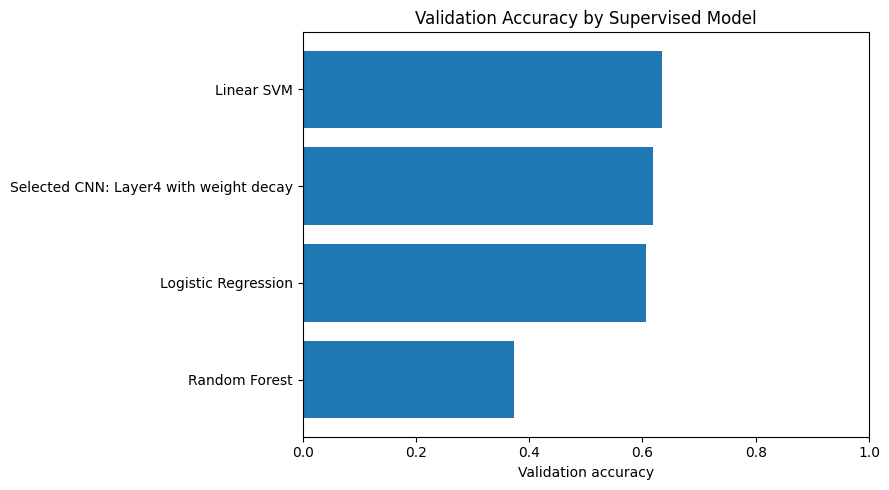

In [115]:
# plot validation accuracy across supervised models
accuracy_plot_df = (
    supervised_comparison_df
    .sort_values("val_accuracy")
)

plt.figure(figsize=(9, 5))

plt.barh(
    accuracy_plot_df["model"],
    accuracy_plot_df["val_accuracy"]
)

plt.title(
    "Validation Accuracy by Supervised Model"
)

plt.xlabel("Validation accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

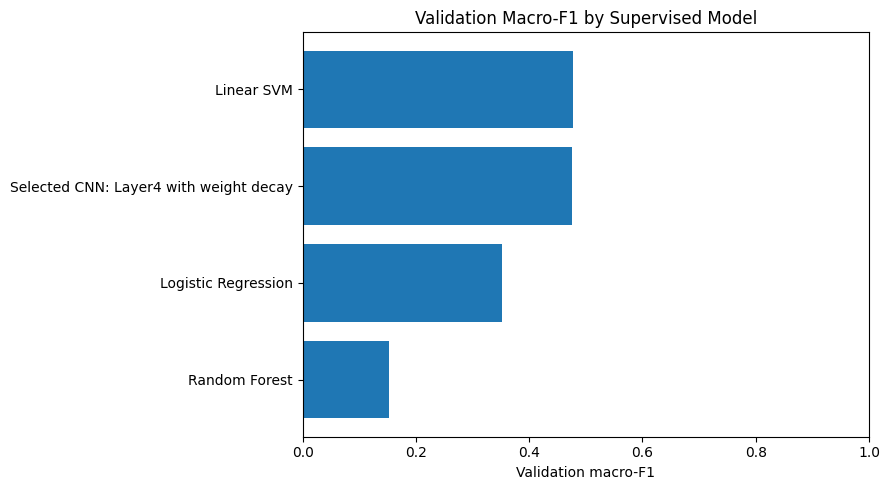

In [116]:
# plot validation macro-F1 across supervised models
macro_f1_plot_df = (
    supervised_comparison_df
    .sort_values("val_macro_f1")
)

plt.figure(figsize=(9, 5))

plt.barh(
    macro_f1_plot_df["model"],
    macro_f1_plot_df["val_macro_f1"]
)

plt.title(
    "Validation Macro-F1 by Supervised Model"
)

plt.xlabel("Validation macro-F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---

## Raw vs Selected CNN Representation Analysis

This section compares the generic ImageNet representation with the representation learned by the selected mushroom classifier.

Both representations use the same validation images and the same class-centroid construction introduced earlier. PCA, UMAP, K-means, and Ward hierarchical clustering are then applied separately to each representation.

These methods are used descriptively rather than as supervised measures of classification performance. Cluster identifiers are arbitrary, so matching numeric or plotted cluster labels across the raw and selected representations do not indicate corresponding clusters.

Only the first two PCA components are plotted, and UMAP axes have no direct feature interpretation. Visible overlap in either two-dimensional projection does not mean that classes are indistinguishable across all 512 embedding features.

### Class-Centroid Helper

In [117]:
# average image embeddings within each mushroom class
def make_species_centroids(
    image_embeddings,
    image_labels
):
    embedding_frame = pd.DataFrame(
        image_embeddings
    )

    embedding_frame["label"] = image_labels

    return (
        embedding_frame
        .groupby("label")
        .mean()
        .sort_index()
    )

### Validation Species Centroids

In [118]:
# collect raw and selected embeddings for the same validation images
raw_val_embeddings = embeddings[
    val_indices
].numpy()

raw_val_labels = labels[
    val_indices
].numpy()

selected_val_embeddings = val_embeddings.numpy()

selected_val_labels = (
    val_embedding_labels.numpy()
)

In [119]:
# verify that both representations use the same images and labels
if not np.array_equal(
    raw_val_labels,
    selected_val_labels
):
    raise ValueError(
        "Raw and selected validation labels do not match."
    )

In [120]:
raw_species_centroids = make_species_centroids(
    raw_val_embeddings,
    raw_val_labels
)

selected_species_centroids = (
    make_species_centroids(
        selected_val_embeddings,
        selected_val_labels
    )
)

In [121]:
# confirm that both representations contain the same classes
if not raw_species_centroids.index.equals(
    selected_species_centroids.index
):
    raise ValueError(
        "Raw and selected species classes do not match."
    )

print(
    "raw species centroids:",
    raw_species_centroids.shape
)

print(
    "selected species centroids:",
    selected_species_centroids.shape
)

raw species centroids: (555, 512)
selected species centroids: (555, 512)


### PCA and UMAP Projections

In [122]:
# create separate PCA projections for both representations
raw_pca = PCA(
    n_components=2,
    random_state=SEED
).fit_transform(
    raw_species_centroids
)

selected_pca = PCA(
    n_components=2,
    random_state=SEED
).fit_transform(
    selected_species_centroids
)

In [123]:
# create separate UMAP projections for both representations
raw_umap = umap.UMAP(
    n_components=2,
    random_state=SEED
).fit_transform(
    raw_species_centroids
)

selected_umap = umap.UMAP(
    n_components=2,
    random_state=SEED
).fit_transform(
    selected_species_centroids
)

c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### K-Means Clustering

In [124]:
# retain the same descriptive cluster count used previously
representation_cluster_count = 20

# cluster raw ImageNet species centroids
raw_kmeans = KMeans(
    n_clusters=representation_cluster_count,
    random_state=SEED,
    n_init=10
)

raw_kmeans_clusters = raw_kmeans.fit_predict(
    raw_species_centroids
)

c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [125]:
# cluster selected-CNN species centroids
selected_kmeans = KMeans(
    n_clusters=representation_cluster_count,
    random_state=SEED,
    n_init=10
)

selected_kmeans_clusters = (
    selected_kmeans.fit_predict(
        selected_species_centroids
    )
)

c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [126]:
print(
    "raw clusters:",
    len(np.unique(raw_kmeans_clusters))
)

print(
    "selected clusters:",
    len(np.unique(selected_kmeans_clusters))
)

raw clusters: 20
selected clusters: 20


### PCA Comparison Plot

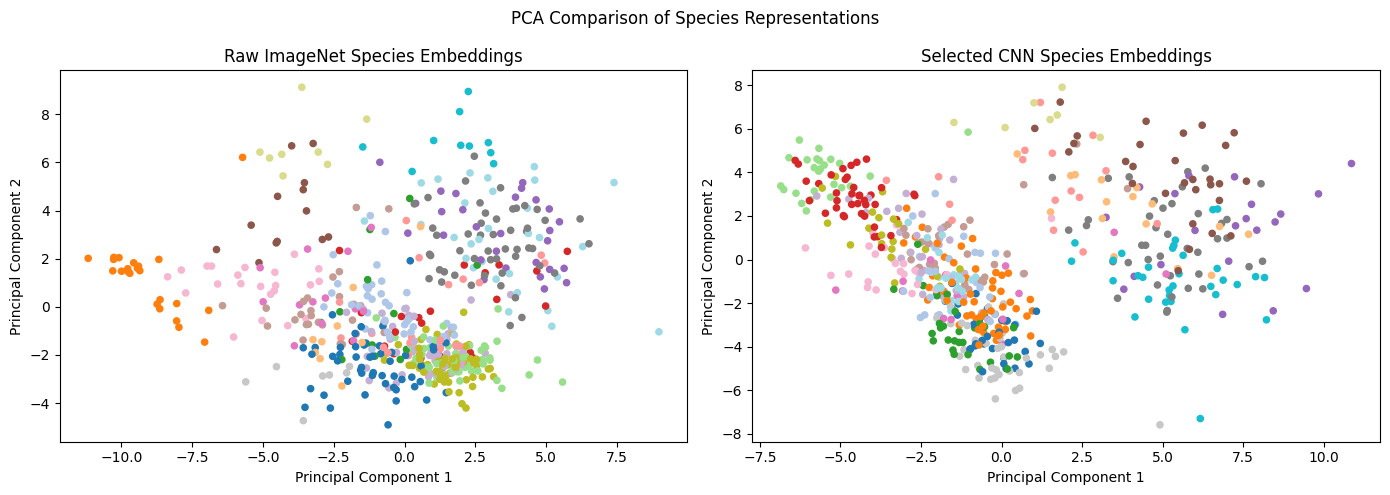

In [127]:
# compare K-means groups in the PCA projections
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].scatter(
    raw_pca[:, 0],
    raw_pca[:, 1],
    c=raw_kmeans_clusters,
    cmap="tab20",
    s=20
)

axes[0].set_title(
    "Raw ImageNet Species Embeddings"
)

axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    selected_pca[:, 0],
    selected_pca[:, 1],
    c=selected_kmeans_clusters,
    cmap="tab20",
    s=20
)

axes[1].set_title(
    "Selected CNN Species Embeddings"
)

axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

fig.suptitle(
    "PCA Comparison of Species Representations"
)

plt.tight_layout()
plt.show()

### UMAP Comparison Plot

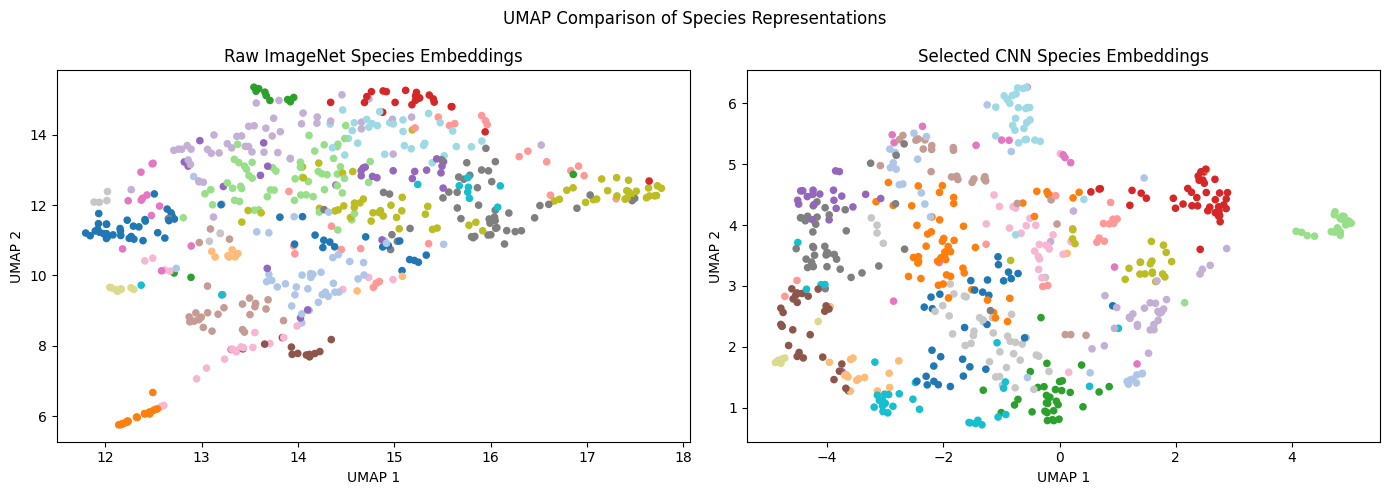

In [128]:
# compare K-means groups in the UMAP projections
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].scatter(
    raw_umap[:, 0],
    raw_umap[:, 1],
    c=raw_kmeans_clusters,
    cmap="tab20",
    s=20
)

axes[0].set_title(
    "Raw ImageNet Species Embeddings"
)

axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

axes[1].scatter(
    selected_umap[:, 0],
    selected_umap[:, 1],
    c=selected_kmeans_clusters,
    cmap="tab20",
    s=20
)

axes[1].set_title(
    "Selected CNN Species Embeddings"
)

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

fig.suptitle(
    "UMAP Comparison of Species Representations"
)

plt.tight_layout()
plt.show()

### Ward Hierarchical Clustering

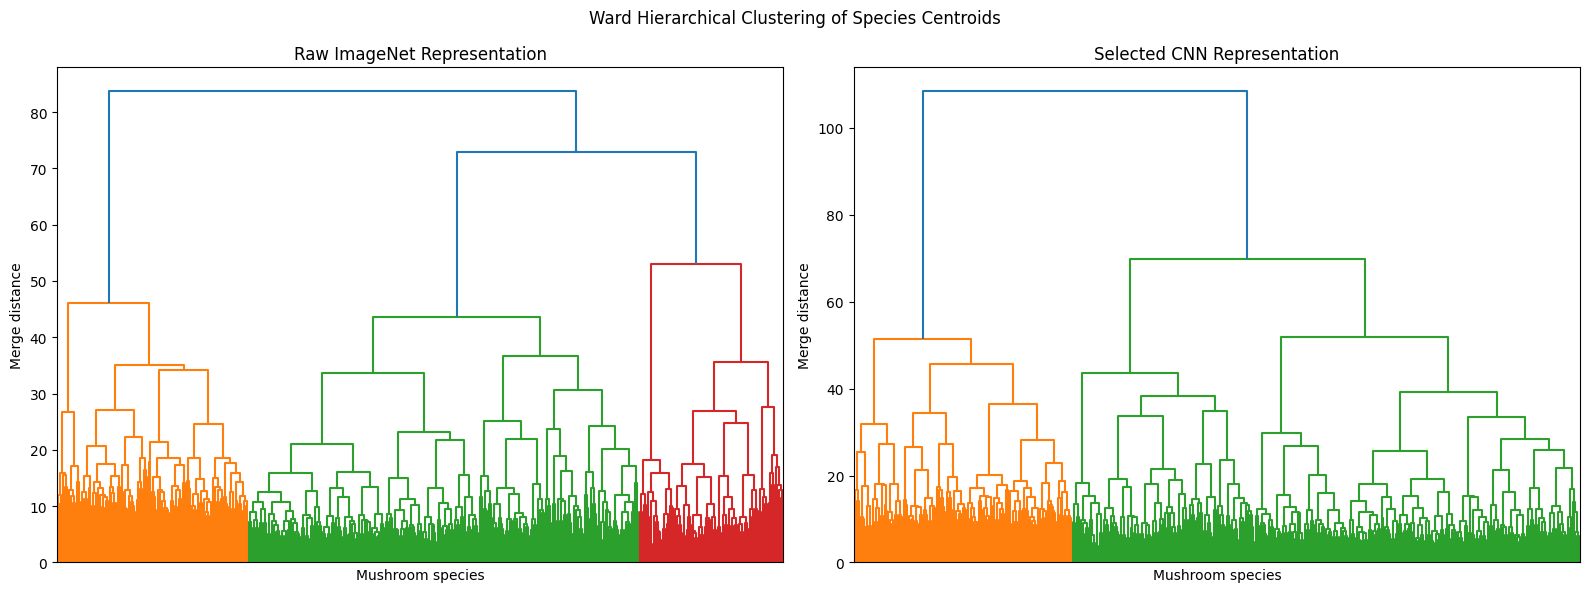

In [129]:
# calculate the hierarchical structure for each representation
raw_linkage = linkage(
    raw_species_centroids,
    method="ward"
)

selected_linkage = linkage(
    selected_species_centroids,
    method="ward"
)

# compare the two dendrograms
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

dendrogram(
    raw_linkage,
    no_labels=True,
    color_threshold=None,
    ax=axes[0]
)

axes[0].set_title(
    "Raw ImageNet Representation"
)

axes[0].set_xlabel("Mushroom species")
axes[0].set_ylabel("Merge distance")

dendrogram(
    selected_linkage,
    no_labels=True,
    color_threshold=None,
    ax=axes[1]
)

axes[1].set_title(
    "Selected CNN Representation"
)

axes[1].set_xlabel("Mushroom species")
axes[1].set_ylabel("Merge distance")

fig.suptitle(
    "Ward Hierarchical Clustering of Species Centroids"
)

plt.tight_layout()
plt.show()

### K-Means Cluster Assignments

In [130]:
# attach class names and genus information to cluster assignments
representation_class_indices = (
    raw_species_centroids.index.to_numpy()
)

representation_cluster_df = pd.DataFrame({
    "class_index": representation_class_indices,
    "class_label": [
        image_dataset.classes[class_index]
        for class_index
        in representation_class_indices
    ],
    "genus": [
        class_genus_names[class_index]
        for class_index
        in representation_class_indices
    ],
    "raw_kmeans_cluster": raw_kmeans_clusters,
    "selected_kmeans_cluster": (
        selected_kmeans_clusters
    )
})

representation_cluster_df.head(20)

,class_index,class_label,genus,raw_kmeans_cluster,selected_kmeans_cluster
0,0,Agaricus arvensis,Agaricus,9,2
1,1,Agaricus augustus,Agaricus,9,11
2,2,Agaricus bernardii,Agaricus,9,2
3,3,Agaricus bisporus,Agaricus,18,10
4,4,Agaricus californicus,Agaricus,8,14
5,5,Agaricus campestris,Agaricus,9,2
6,6,Agaricus hondensis,Agaricus,8,14
7,7,Agaricus menieri,Agaricus,14,14
8,8,Agaricus moelleri,Agaricus,19,14
9,9,Agaricus phaeolepidotus,Agaricus,5,14


---

## Summary and Limitations

The CNN experiments show that adapting the deepest ResNet18 feature block substantially improves exact-class and macro-F1 performance over training only the final classifier. Weight decay is evaluated as a controlled regularization change, and the final CNN is selected using validation macro-F1 with validation loss as a near-tie criterion.

The traditional classifiers provide reference baselines for the usefulness of the selected CNN embeddings. The PCA, UMAP, K-means, and Ward analyses then compare how generic ImageNet features and mushroom-trained features organize the species classes.

The results remain limited by severe class imbalance, possible label noise, visually similar species, uncontrolled image backgrounds, and the absence of non-image identification evidence. Top-k and genus-level results should therefore be interpreted as identification-support measures rather than proof of reliable standalone mushroom identification.